# 1.IMPORTING LIBRARIES

In [172]:
pip install xgboost


In [173]:
#importing the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import scipy.stats as stats
import statistics
from scipy import stats
from sklearn.feature_selection import chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.feature_selection import f_classif


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix




import warnings
# # Suppressing a warning 
warnings.filterwarnings("ignore") 
warnings.warn("this will not show")

import re
import time
import random

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# 2.LOADING DATASET

In [174]:
#loading  the credit classification dataset
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

#  3.TRAIN AND TEST DATA HEAD,SHPE,SIZE,INFO,STATISTICS

In [175]:
df_train.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [176]:
df_train.shape

(100000, 28)

In [177]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [178]:
df_train.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,84998.0,4194.170850,3183.686167,303.645417,1625.568229,3093.745000,5957.448333,15204.633333
Num_Bank_Accounts,100000.0,17.091280,117.404834,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,100000.0,22.474430,129.057410,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,100000.0,72.466040,466.422621,1.000000,8.000000,13.000000,20.000000,5797.000000
Delay_from_due_date,100000.0,21.068780,14.860104,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,98035.0,27.754251,193.177339,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,100000.0,32.285173,5.116875,20.000000,28.052567,32.305784,36.496663,50.000000
Total_EMI_per_month,100000.0,1403.118217,8306.041270,0.000000,30.306660,69.249473,161.224249,82331.000000


In [179]:
#Check statistical values for fields with other than numerical datatype
df_train.describe(exclude=np.number).T

,count,unique,top,freq
ID,100000,100000,0x1602,1
Customer_ID,100000,12500,CUS_0xd40,8
Month,100000,8,January,12500
Name,90015,10139,Langep,44
Age,100000,1788,38,2833
SSN,100000,12501,#F%$D@*&8,5572
Occupation,100000,16,_______,7062
Annual_Income,100000,18940,36585.12,16
Num_of_Loan,100000,434,3,14386
Type_of_Loan,88592,6260,Not Specified,1408


In [180]:
df_train.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [181]:
df_train.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                         9985
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       15002
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                11408
Delay_from_due_date             0
Num_of_Delayed_Payment       7002
Changed_Credit_Limit            0
Num_Credit_Inquiries         1965
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age           9030
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      4479
Payment_Behaviour               0
Monthly_Balance              1200
Credit_Score                    0
dtype: int64

In [182]:
# numerical columns of the data
num_cols = df_train.select_dtypes(include=['float64', 'int64']).columns
num_cols

Index(['Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card',
       'Interest_Rate', 'Delay_from_due_date', 'Num_Credit_Inquiries',
       'Credit_Utilization_Ratio', 'Total_EMI_per_month'],
      dtype='object')

In [183]:
# categorical columns of the data 
cat_cols = df_train.select_dtypes(include=['object']).columns
cat_cols

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [184]:
print(df_train.dtypes)  # Check data types



ID                           object
Customer_ID                  object
Month                        object
Name                         object
Age                          object
SSN                          object
Occupation                   object
Annual_Income                object
Monthly_Inhand_Salary       float64
Num_Bank_Accounts             int64
Num_Credit_Card               int64
Interest_Rate                 int64
Num_of_Loan                  object
Type_of_Loan                 object
Delay_from_due_date           int64
Num_of_Delayed_Payment       object
Changed_Credit_Limit         object
Num_Credit_Inquiries        float64
Credit_Mix                   object
Outstanding_Debt             object
Credit_Utilization_Ratio    float64
Credit_History_Age           object
Payment_of_Min_Amount        object
Total_EMI_per_month         float64
Amount_invested_monthly      object
Payment_Behaviour            object
Monthly_Balance              object
Credit_Score                

In [185]:
df_test.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [186]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

In [187]:
df_test.shape

(50000, 27)

In [188]:
df_test.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,42502.0,4182.004291,3174.109304,303.645417,1625.188333,3086.305000,5934.189094,15204.633333
Num_Bank_Accounts,50000.0,16.838260,116.396848,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,50000.0,22.921480,129.314804,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,50000.0,68.772640,451.602363,1.000000,8.000000,13.000000,20.000000,5799.000000
Delay_from_due_date,50000.0,21.052640,14.860397,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,48965.0,30.080200,196.984121,0.000000,4.000000,7.000000,10.000000,2593.000000
Credit_Utilization_Ratio,50000.0,32.279581,5.106238,20.509652,28.061040,32.280390,36.468591,48.540663
Total_EMI_per_month,50000.0,1491.304305,8595.647887,0.000000,32.222388,74.733349,176.157491,82398.000000


In [189]:
#Check statistical values for fields with other than numerical datatype
df_test.describe(exclude=np.number).T

,count,unique,top,freq
ID,50000,50000,0x160a,1
Customer_ID,50000,12500,CUS_0xd40,4
Month,50000,4,September,12500
Name,44985,10139,Stevex,22
Age,50000,976,39,1493
SSN,50000,12501,#F%$D@*&8,2828
Occupation,50000,16,_______,3438
Annual_Income,50000,16121,109945.32,8
Num_of_Loan,50000,263,2,7173
Type_of_Loan,44296,6260,Not Specified,704


In [190]:
df_test.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

In [191]:
df_test.isnull().sum()

ID                             0
Customer_ID                    0
Month                          0
Name                        5015
Age                            0
SSN                            0
Occupation                     0
Annual_Income                  0
Monthly_Inhand_Salary       7498
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                5704
Delay_from_due_date            0
Num_of_Delayed_Payment      3498
Changed_Credit_Limit           0
Num_Credit_Inquiries        1035
Credit_Mix                     0
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          4470
Payment_of_Min_Amount          0
Total_EMI_per_month            0
Amount_invested_monthly     2271
Payment_Behaviour              0
Monthly_Balance              562
dtype: int64

# 4.CONCATING DATASETS

In [192]:
df = pd.concat([df_train, df_test], ignore_index=True)
df.shape

(150000, 28)

# 5.FINAL CONCAT DATASET HEAD,COLUMNS,MISSING VALUES,SHAPE,STATISTICS,INFO

In [193]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [194]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  object 
 1   Customer_ID               150000 non-null  object 
 2   Month                     150000 non-null  object 
 3   Name                      135000 non-null  object 
 4   Age                       150000 non-null  object 
 5   SSN                       150000 non-null  object 
 6   Occupation                150000 non-null  object 
 7   Annual_Income             150000 non-null  object 
 8   Monthly_Inhand_Salary     127500 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  int64  
 10  Num_Credit_Card           150000 non-null  int64  
 11  Interest_Rate             150000 non-null  int64  
 12  Num_of_Loan               150000 non-null  object 
 13  Type_of_Loan              132888 non-null  o

In [195]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Monthly_Inhand_Salary,127500.0,4190.115139,3180.489657,303.645417,1625.265833,3091.000000,5948.454596,15204.633333
Num_Bank_Accounts,150000.0,17.006940,117.069476,-1.000000,3.000000,6.000000,7.000000,1798.000000
Num_Credit_Card,150000.0,22.623447,129.143006,0.000000,4.000000,5.000000,7.000000,1499.000000
Interest_Rate,150000.0,71.234907,461.537193,1.000000,8.000000,13.000000,20.000000,5799.000000
Delay_from_due_date,150000.0,21.063400,14.860154,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_Credit_Inquiries,147000.0,28.529014,194.456058,0.000000,3.000000,6.000000,9.000000,2597.000000
Credit_Utilization_Ratio,150000.0,32.283309,5.113315,20.000000,28.054731,32.297058,36.487954,50.000000
Total_EMI_per_month,150000.0,1432.513579,8403.759977,0.000000,30.947775,71.280006,166.279555,82398.000000


In [196]:
#Check statistical values for fields with other than numerical datatype
df.describe(exclude=np.number).T

,count,unique,top,freq
ID,150000,150000,0x1602,1
Customer_ID,150000,12500,CUS_0xd40,12
Month,150000,12,January,12500
Name,135000,10139,Stevex,66
Age,150000,2524,39,4198
SSN,150000,12501,#F%$D@*&8,8400
Occupation,150000,16,_______,10500
Annual_Income,150000,21192,36585.12,24
Num_of_Loan,150000,623,3,21500
Type_of_Loan,132888,6260,Not Specified,2112


In [197]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

In [198]:
df.isnull().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                        15000
Age                             0
SSN                             0
Occupation                      0
Annual_Income                   0
Monthly_Inhand_Salary       22500
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                17112
Delay_from_due_date             0
Num_of_Delayed_Payment      10500
Changed_Credit_Limit            0
Num_Credit_Inquiries         3000
Credit_Mix                      0
Outstanding_Debt                0
Credit_Utilization_Ratio        0
Credit_History_Age          13500
Payment_of_Min_Amount           0
Total_EMI_per_month             0
Amount_invested_monthly      6750
Payment_Behaviour               0
Monthly_Balance              1762
Credit_Score                50000
dtype: int64

# 6.DATA VISUALIZATION BEFORE CLEANING 

## 6A.NUMERICAL FEATURES

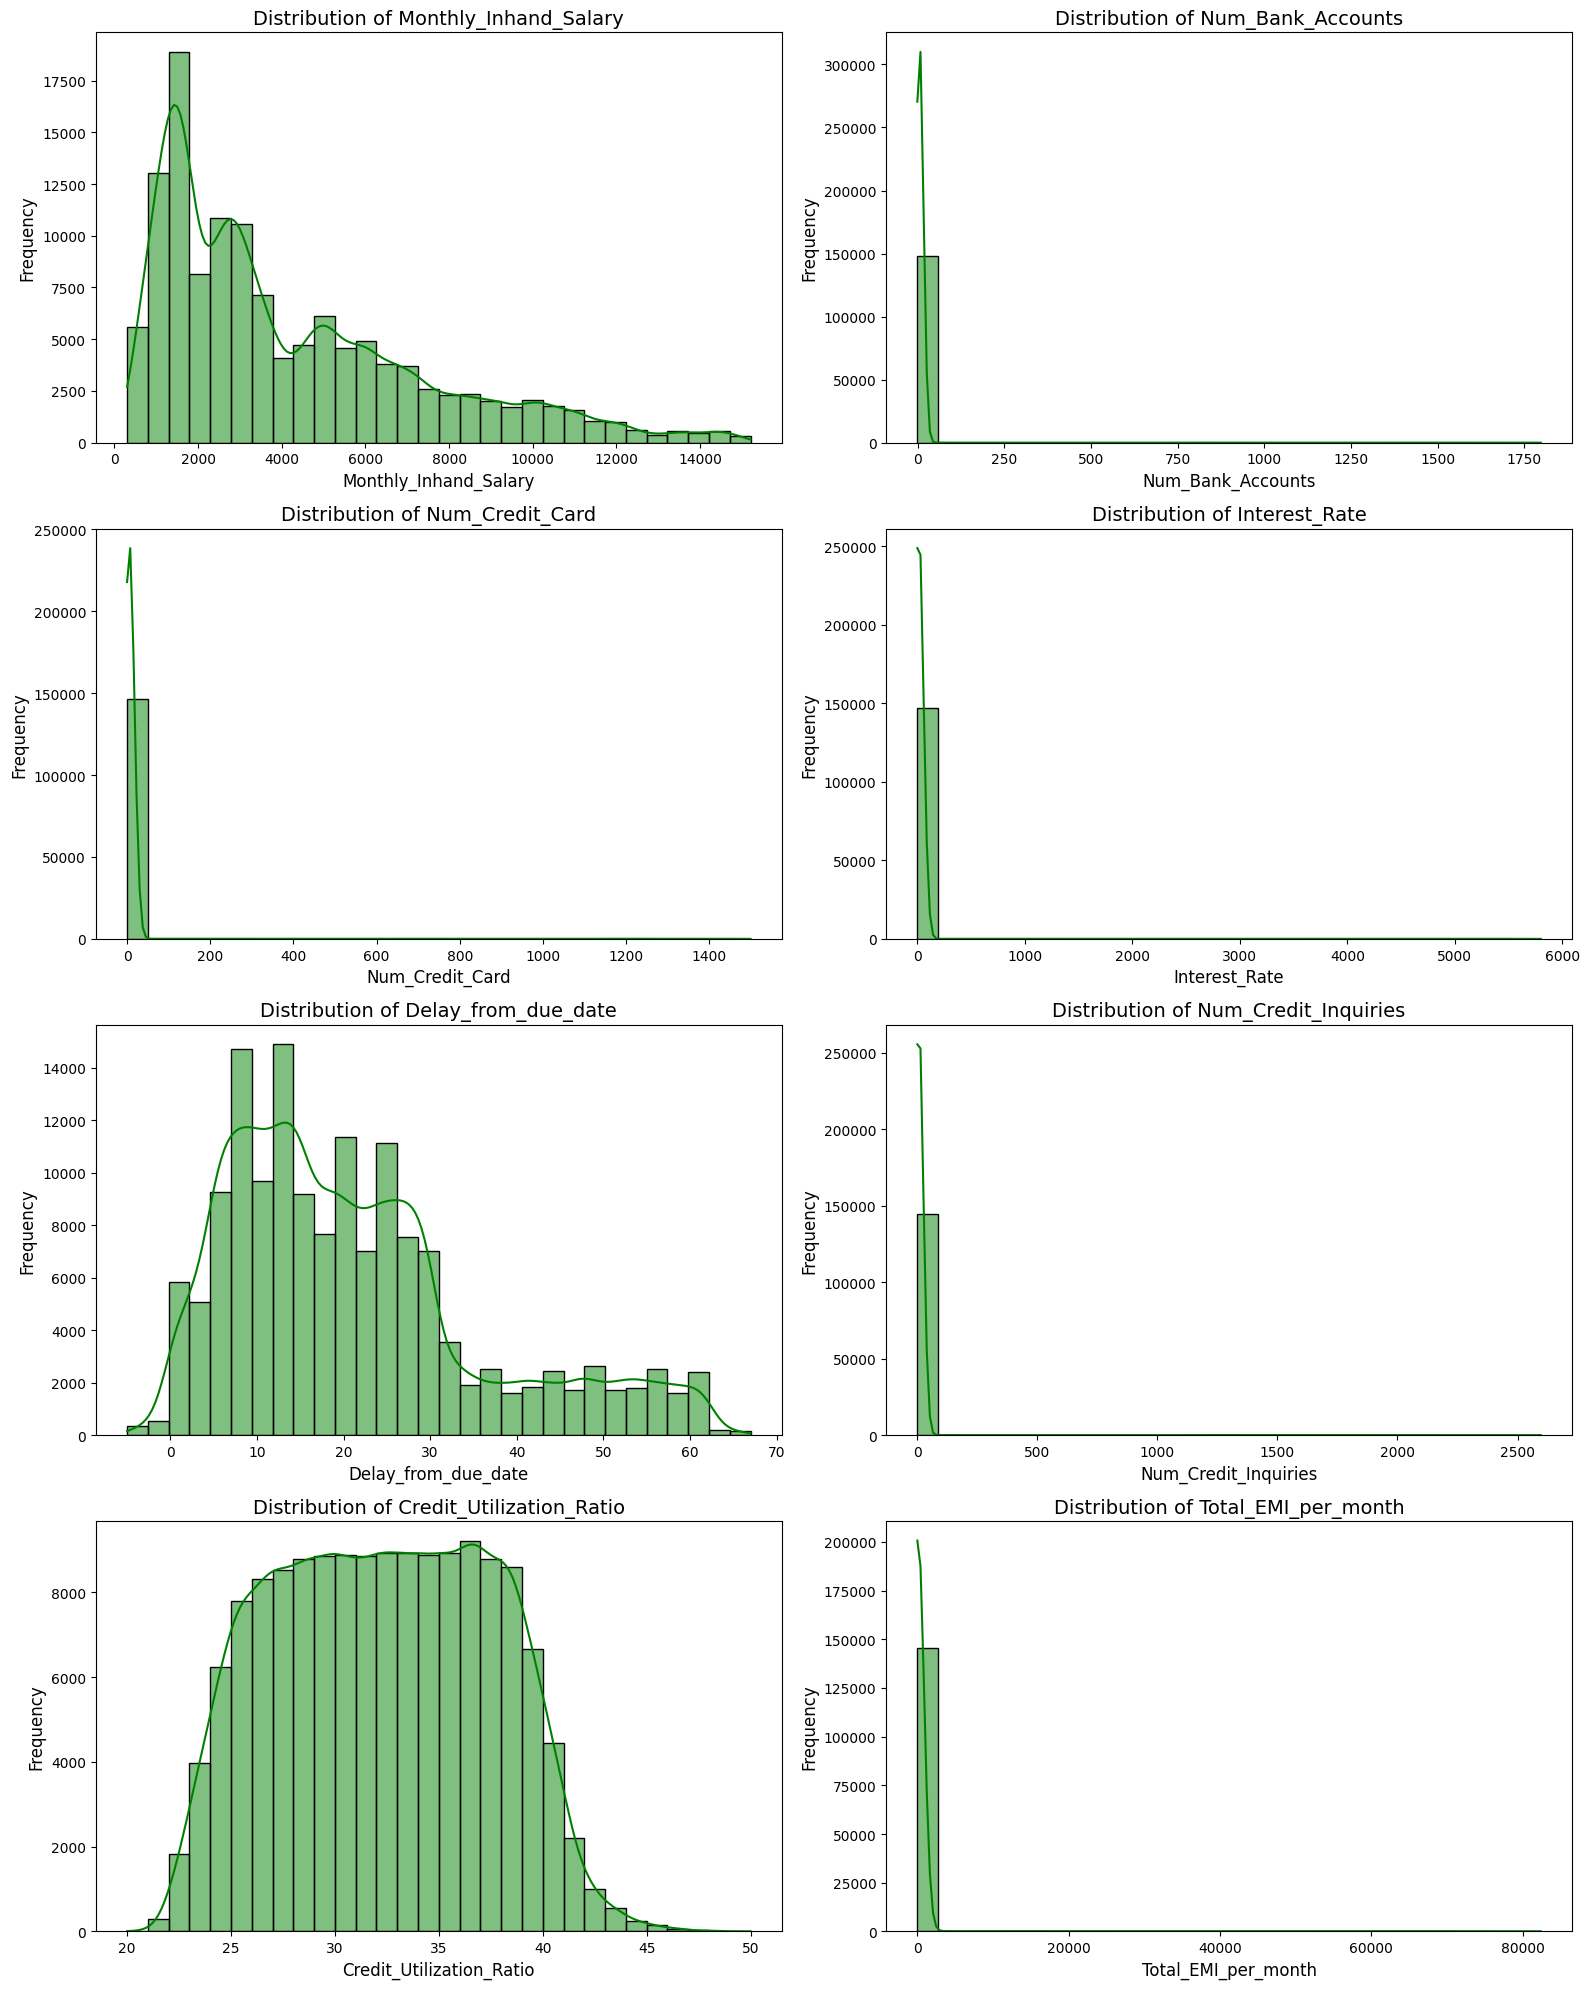

In [199]:
# Set up the plotting area
plt.figure(figsize=(16, 20))
for i, feature in enumerate(num_cols, 1):
    plt.subplot(4, 2, i)  # Adjust rows and columns for subplots
    sns.histplot(df[feature], kde=True, bins=30, color='green',edgecolor='black')
    plt.title(f"Distribution of {feature}", fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Frequency", fontsize=12)
    plt.tight_layout()

# Show the plots
plt.show()


## 6B.CATEGORICAL FEATURES

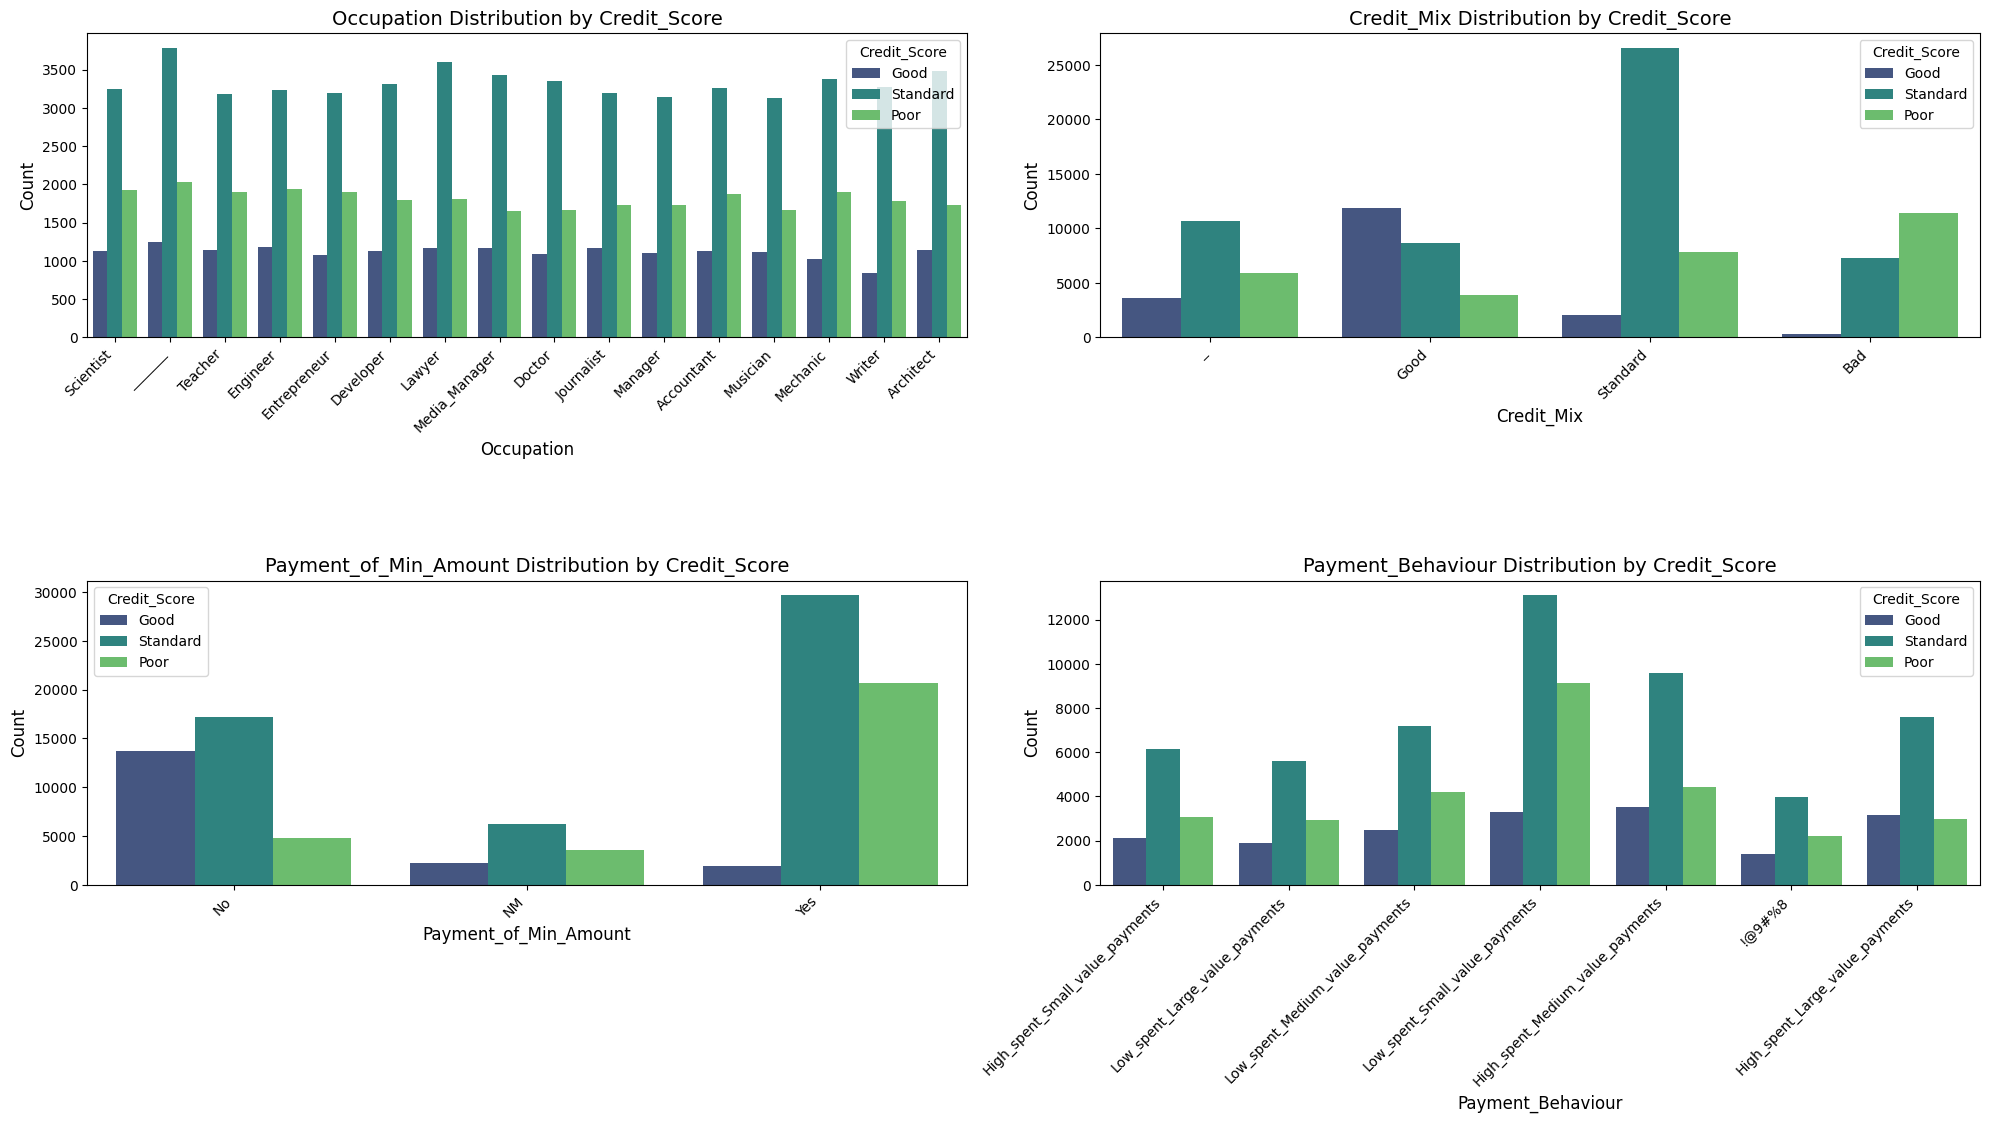

In [200]:
# List of categorical features to visualize
categorical_features = [
    'Occupation', 
    'Credit_Mix',
    'Payment_of_Min_Amount', 
    'Payment_Behaviour', 
    'Credit_Score'
]



# Increase figure size
plt.figure(figsize=(20, 20))  # Adjust to larger dimensions
for i, feature in enumerate(categorical_features[:-1], 1):
    plt.subplot(4, 2, i)  # Adjust rows and columns
    sns.countplot(data=df, x=feature, hue="Credit_Score", palette="viridis")
    plt.title(f"{feature} Distribution by Credit_Score", fontsize=14)
    plt.xlabel(feature, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()


# Show the plots
plt.show()



# 7.CHECKING DATA

In [201]:
object_col = df.describe(include='O').columns
object_col

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Num_of_Loan', 'Type_of_Loan',
       'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Credit_Mix',
       'Outstanding_Debt', 'Credit_History_Age', 'Payment_of_Min_Amount',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score'],
      dtype='object')

# 7A.DETECTING STRANGE VALUES IN DATASET

In [202]:
for col in object_col:
    print('Column Name: '+col)
    print("**"*20)
    print(df_train[col].value_counts(dropna=False))
    print('END', "--"*18, '\n')

Column Name: ID
****************************************
ID
0x1602     1
0x19c88    1
0x19caa    1
0x19ca5    1
0x19ca4    1
          ..
0xd94d     1
0xd94c     1
0xd94b     1
0xd94a     1
0x25fed    1
Name: count, Length: 100000, dtype: int64
END ------------------------------------ 

Column Name: Customer_ID
****************************************
Customer_ID
CUS_0xd40     8
CUS_0x9bf4    8
CUS_0x5ae3    8
CUS_0xbe9a    8
CUS_0x4874    8
             ..
CUS_0x2eb4    8
CUS_0x7863    8
CUS_0x9d89    8
CUS_0xc045    8
CUS_0x942c    8
Name: count, Length: 12500, dtype: int64
END ------------------------------------ 

Column Name: Month
****************************************
Month
January     12500
February    12500
March       12500
April       12500
May         12500
June        12500
July        12500
August      12500
Name: count, dtype: int64
END ------------------------------------ 

Column Name: Name
****************************************
Name
NaN               9985
Stevex  

## 7B.DATACLEANING OTHER THAN NULL VALUE HANDLING 

In [203]:
def text_cleaning(data):
    if data is np.NaN or not isinstance(data, str):
        return data
    else:
        return str(data).strip('_ ,"')

In [204]:
df = df.applymap(text_cleaning).replace(['', 'nan', '!@9#%8', '#F%$D@*&8'], np.NaN)
df

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,NaN,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,0x25fe5,CUS_0x8600,December,Sarah McBridec,4975,031-35-0942,Architect,20002.88,1929.906667,10,...,NaN,3571.7,34.780553,NaN,Yes,60.964772,146.48632477751087,Low_spent_Small_value_payments,275.53956951573343,NaN
149996,0x25fee,CUS_0x942c,September,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,Good,502.38,27.758522,31 Years and 11 Months,NM,35.104023,181.44299902757518,Low_spent_Small_value_payments,409.39456169535066,NaN
149997,0x25fef,CUS_0x942c,October,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,36.858542,32 Years and 0 Months,No,35.104023,10000,Low_spent_Large_value_payments,349.7263321025098,NaN
149998,0x25ff0,CUS_0x942c,November,Nicks,25,078-73-5990,Mechanic,39628.99,NaN,4,...,Good,502.38,39.139840,32 Years and 1 Months,No,35.104023,97.59857973344877,High_spent_Small_value_payments,463.23898098947717,NaN


# 7C.CHANGING DATATYPES

In [205]:
df['ID']                      = df.ID.apply(lambda x: int(x, 16))
df['Customer_ID']             = df.Customer_ID.apply(lambda x: int(x[4:], 16))
df['Month']                   = pd.to_datetime(df.Month, format='%B').dt.month
df['Age']                     = df.Age.astype(int) 
df['SSN']                     = df.SSN.apply(lambda x: x if x is np.NaN else int(str(x).replace('-', ''))).astype(float)
df['Annual_Income']           = df.Annual_Income.astype(float)
df['Num_of_Loan']             = df.Num_of_Loan.astype(int) 
df['Num_of_Delayed_Payment']  = df.Num_of_Delayed_Payment.astype(float)
df['Changed_Credit_Limit']    = df.Changed_Credit_Limit.astype(float)
df['Outstanding_Debt']        = df.Outstanding_Debt.astype(float)
df['Amount_invested_monthly'] = df.Amount_invested_monthly.astype(float)
df['Monthly_Balance']         = df.Monthly_Balance.astype(float)

### 7D MONTH CONVERTER FROM YEARS TO MONTHS

In [206]:
def Month_Converter(x):
    if pd.notnull(x):
        num1 = int(x.split(' ')[0])
        num2 = int(x.split(' ')[3])
      
        return (num1*12)+num2
    else:
        return x


### 7E.USING GROUPBY FUNCTION FOR FEATURES WITH Customer_ID

In [207]:
df['Credit_History_Age'] = df.Credit_History_Age.apply(lambda x: Month_Converter(x)).astype(float)


In [208]:

df.groupby('Customer_ID')['Credit_History_Age'].apply(list)

Customer_ID
1006     [182.0, 183.0, 184.0, 185.0, 186.0, 187.0, 188...
1007     [346.0, 347.0, 348.0, 349.0, 350.0, nan, 352.0...
1008     [292.0, 293.0, 294.0, nan, 296.0, 297.0, 298.0...
1009     [331.0, 332.0, 333.0, 334.0, 335.0, 336.0, 337...
1011     [179.0, 180.0, nan, 182.0, 183.0, 184.0, 185.0...
                               ...                        
50984    [157.0, 158.0, 159.0, nan, 161.0, 162.0, nan, ...
50990    [70.0, 71.0, 72.0, nan, nan, 75.0, 76.0, 77.0,...
50992    [159.0, 160.0, 161.0, 162.0, 163.0, nan, 165.0...
50996    [206.0, 207.0, 208.0, 209.0, 210.0, 211.0, 212...
50999    [226.0, 227.0, 228.0, 229.0, 230.0, 231.0, 232...
Name: Credit_History_Age, Length: 12500, dtype: object

In [209]:
df['Type_of_Loan'].value_counts(dropna=False).head(20)


Type_of_Loan
NaN                                         17112
Not Specified                                2112
Credit-Builder Loan                          1920
Personal Loan                                1908
Debt Consolidation Loan                      1896
Student Loan                                 1860
Payday Loan                                  1800
Mortgage Loan                                1764
Auto Loan                                    1728
Home Equity Loan                             1704
Personal Loan, and Student Loan               480
Not Specified, and Payday Loan                408
Mortgage Loan, and Home Equity Loan           396
Student Loan, and Payday Loan                 384
Student Loan, and Credit-Builder Loan         372
Credit-Builder Loan, and Not Specified        372
Payday Loan, and Debt Consolidation Loan      360
Payday Loan, and Auto Loan                    360
Mortgage Loan, and Not Specified              348
Payday Loan, and Personal Loan       

In [210]:
df.groupby('Customer_ID')['Type_of_Loan'].value_counts(dropna=False)

Customer_ID  Type_of_Loan                                                                                         
1006         Credit-Builder Loan, and Payday Loan                                                                     12
1007         Home Equity Loan, Mortgage Loan, and Student Loan                                                        12
1008         NaN                                                                                                      12
1009         Credit-Builder Loan, Student Loan, Not Specified, and Student Loan                                       12
1011         Personal Loan, Auto Loan, and Auto Loan                                                                  12
                                                                                                                      ..
50984        Home Equity Loan, Mortgage Loan, Payday Loan, Mortgage Loan, Mortgage Loan, and Payday Loan              12
50990        Mortgage Loan, Auto Loan,

In [ ]:
df.groupby('Customer_ID')['Type_of_Loan'].apply(list)

Customer_ID
1006     [Credit-Builder Loan, and Payday Loan, Credit-...
1007     [Home Equity Loan, Mortgage Loan, and Student ...
1008     [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
1009     [Credit-Builder Loan, Student Loan, Not Specif...
1011     [Personal Loan, Auto Loan, and Auto Loan, Pers...
                               ...                        
50984    [Home Equity Loan, Mortgage Loan, Payday Loan,...
50990    [Mortgage Loan, Auto Loan, and Auto Loan, Mort...
50992    [Student Loan, Credit-Builder Loan, Mortgage L...
50996    [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...
50999    [Credit-Builder Loan, Credit-Builder Loan, Cre...
Name: Type_of_Loan, Length: 12500, dtype: object

### 7F CHECKING DIFFERENT VALUES

In [212]:
def get_Diff_Values_Colum(df_column, diff_value=[], sep=',', replace=''):   
    column = df_column.dropna()
    for i in column:
        if sep not in i and i not in diff_value:
            diff_value.append(i)
        else:
            for data in map(lambda x:x.strip(), re.sub(replace, '', i).split(sep)):
                if not data in diff_value:
                    diff_value.append(data)
    return dict(enumerate(sorted(diff_value)))


In [213]:
get_Diff_Values_Colum(df['Type_of_Loan'])

{0: 'Auto Loan',
 1: 'Credit-Builder Loan',
 2: 'Debt Consolidation Loan',
 3: 'Home Equity Loan',
 4: 'Mortgage Loan',
 5: 'Not Specified',
 6: 'Payday Loan',
 7: 'Personal Loan',
 8: 'Student Loan',
 9: 'and Auto Loan',
 10: 'and Credit-Builder Loan',
 11: 'and Debt Consolidation Loan',
 12: 'and Home Equity Loan',
 13: 'and Mortgage Loan',
 14: 'and Not Specified',
 15: 'and Payday Loan',
 16: 'and Personal Loan',
 17: 'and Student Loan'}

# 8. DATA PREPROCESSING

### 8A.OBJECT NAN VALUE HANDLING : GROUP MODE 

In [ ]:
# Define function to handle missing values for object columns
def Object_NaN_Values_Reassign_Group_Mode(df, groupby, column, inplace=True):
    def make_NaN_and_fill_mode(df, groupby, column, inplace=True):
        # Replace None with NaN
        df[column] = df[column].replace([None], np.NaN)

        # Fill with local mode for each group
        result = df.groupby(groupby)[column].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else None))

        if inplace:
            df[column] = result
        else:
            return result

    # Main Execution
    if inplace:
        # Log the current status
        if df[column].isna().sum():
            print(f'\nBefore Assigning: {column} has {df[column].isna().sum()} NaN values.\n')

        # Before modification example
        print(f'\nBefore Assigning Example {column}:')
        print(df.groupby(groupby)[column].apply(list).head().values)

        # Assign NaN and fill
        make_NaN_and_fill_mode(df, groupby, column, inplace)

        # Log the final status
        if df[column].isna().sum():
            print(f'\nAfter Assigning: {column} has {df[column].isna().sum()} NaN values.\n')

        print(f'\nAfter Assigning Example {column}:')
        print(df.groupby(groupby)[column].apply(list).head().values)
    else:
        return make_NaN_and_fill_mode(df, groupby, column, inplace=False)





In [215]:
df['Name'].value_counts(dropna=False).head()


Name
NaN         15000
Stevex         66
Langep         65
Jessicad       59
Johnc          58
Name: count, dtype: int64

In [216]:
Object_NaN_Values_Reassign_Group_Mode(df, 'Customer_ID', 'Name')


Before Assigning: Name has 15000 NaN values.


Before Assigning Example Name:
[list(['Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', nan, nan, 'Matthias Blamontb', nan, 'Matthias Blamontb'])
 list([nan, 'Soyoung Kimu', 'Soyoung Kimu', 'Soyoung Kimu', 'Soyoung Kimu', nan, nan, 'Soyoung Kimu', 'Soyoung Kimu', 'Soyoung Kimu', nan, 'Soyoung Kimu'])
 list(['Koht', 'Koht', 'Koht', 'Koht', 'Koht', 'Koht', 'Koht', nan, 'Koht', 'Koht', 'Koht', 'Koht'])
 list(['Edd', 'Edd', 'Edd', 'Edd', 'Edd', 'Edd', 'Edd', 'Edd', 'Edd', 'Edd', 'Edd', nan])
 list(['Terry Wadeu', 'Terry Wadeu', 'Terry Wadeu', 'Terry Wadeu', 'Terry Wadeu', 'Terry Wadeu', 'Terry Wadeu', nan, nan, 'Terry Wadeu', 'Terry Wadeu', nan])]

After Assigning Example Name:
[list(['Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb', 'Matthias Blamontb

In [217]:
df['Occupation'].value_counts(dropna=False)

Occupation
NaN              10500
Lawyer            9899
Engineer          9562
Architect         9550
Mechanic          9459
Accountant        9404
Scientist         9403
Developer         9381
Media_Manager     9362
Teacher           9318
Entrepreneur      9277
Journalist        9122
Doctor            9114
Manager           8973
Musician          8858
Writer            8818
Name: count, dtype: int64

In [218]:
df.groupby('Customer_ID')['Type_of_Loan'].value_counts(dropna=False)

Customer_ID  Type_of_Loan                                                                                         
1006         Credit-Builder Loan, and Payday Loan                                                                     12
1007         Home Equity Loan, Mortgage Loan, and Student Loan                                                        12
1008         NaN                                                                                                      12
1009         Credit-Builder Loan, Student Loan, Not Specified, and Student Loan                                       12
1011         Personal Loan, Auto Loan, and Auto Loan                                                                  12
                                                                                                                      ..
50984        Home Equity Loan, Mortgage Loan, Payday Loan, Mortgage Loan, Mortgage Loan, and Payday Loan              12
50990        Mortgage Loan, Auto Loan,

In [219]:
df['Type_of_Loan'].replace([np.NaN], 'No Data', inplace=True)

In [220]:
df['Credit_Mix'].value_counts(dropna=False)

Credit_Mix
Standard    54858
Good        36597
NaN         30000
Bad         28545
Name: count, dtype: int64

In [221]:
Object_NaN_Values_Reassign_Group_Mode(df, 'Customer_ID', 'Credit_Mix')


Before Assigning: Credit_Mix has 30000 NaN values.


Before Assigning Example Credit_Mix:
[list(['Standard', 'Standard', 'Standard', 'Standard', 'Standard', nan, 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard'])
 list([nan, 'Standard', 'Standard', 'Standard', nan, 'Standard', nan, 'Standard', 'Standard', 'Standard', 'Standard', 'Standard'])
 list([nan, 'Standard', 'Standard', nan, 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard'])
 list(['Standard', nan, 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', nan, 'Standard', 'Standard'])
 list([nan, nan, 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard'])]

After Assigning Example Credit_Mix:
[list(['Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard', 'Standard'])
 list(['Standard', 'Standard'

In [222]:
df['Payment_of_Min_Amount'].value_counts(dropna=False)

Payment_of_Min_Amount
Yes    78484
No     53516
NM     18000
Name: count, dtype: int64

In [223]:
df['Payment_Behaviour'].value_counts(dropna=False)

Payment_Behaviour
Low_spent_Small_value_payments      38207
High_spent_Medium_value_payments    26462
Low_spent_Medium_value_payments     20698
High_spent_Large_value_payments     20565
High_spent_Small_value_payments     16991
Low_spent_Large_value_payments      15677
NaN                                 11400
Name: count, dtype: int64

In [224]:
Object_NaN_Values_Reassign_Group_Mode(df, 'Customer_ID', 'Payment_Behaviour')


Before Assigning: Payment_Behaviour has 11400 NaN values.


Before Assigning Example Payment_Behaviour:
[list(['High_spent_Medium_value_payments', 'Low_spent_Medium_value_payments', 'Low_spent_Small_value_payments', 'High_spent_Small_value_payments', 'Low_spent_Large_value_payments', nan, 'Low_spent_Large_value_payments', 'Low_spent_Small_value_payments', 'Low_spent_Small_value_payments', 'Low_spent_Medium_value_payments', 'Low_spent_Small_value_payments', 'Low_spent_Small_value_payments'])
 list(['High_spent_Medium_value_payments', 'High_spent_Medium_value_payments', 'Low_spent_Small_value_payments', 'High_spent_Medium_value_payments', 'Low_spent_Small_value_payments', nan, 'Low_spent_Small_value_payments', 'Low_spent_Small_value_payments', 'Low_spent_Medium_value_payments', 'Low_spent_Large_value_payments', 'Low_spent_Small_value_payments', 'Low_spent_Small_value_payments'])
 list(['High_spent_Small_value_payments', 'Low_spent_Large_value_payments', 'Low_spent_Small_value_payments',

In [225]:
df['Customer_ID'].nunique()


12500

### 8B.OUTLIER DETECTION AND HANDLING

In [226]:
def get_iqr_lower_upper(df, column, multiply=1.5):
    """
    Compute the IQR-based lower and upper bounds for outlier detection.
    """
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - iqr * multiply
    upper = q3 + iqr * multiply

    outlier_count = df.loc[(df[column] < lower) | (df[column] > upper)].shape[0]
    print(f"Outliers: {outlier_count}")
    return lower, upper


def Numeric_Wrong_Values_Reassign_Group_Min_Max(df, groupby, column, multiply=1.5, inplace=True):
    """
    Clean numerical fields by detecting and correcting wrong values using IQR and group statistics.
    """
    import numpy as np
    from scipy.stats import mode

    # Assigning Wrong Values
    def make_group_NaN_and_fill_mode(df, groupby, column, inplace=True):
        """
        Assign outliers to NaN and fill with the mode of the respective group.
        """
        lower, upper = get_iqr_lower_upper(df, column, multiply)

        # Assign values outside range to NaN
        df[column] = df[column].apply(lambda x: np.NaN if (x < lower or x > upper) else x)

        # Fill NaN with local mode (group-wise)
        mode_by_group = df.groupby(groupby)[column].transform(
            lambda x: x.mode()[0] if not x.mode().empty else np.NaN
        )
        result = df[column].fillna(mode_by_group)

        if inplace:
            df[column] = result
        else:
            return result

    # Main Execution
    if inplace:
        # Before Assigning NaN values
        print(f"\nExisting Min, Max Values for {column}:")
        print(df[column].agg(['min', 'max']))

        lower, upper = get_iqr_lower_upper(df, column, multiply)
        print(f"\nIQR-Based Range for {column}: [{lower}, {upper}]\n")

        # Before modification example
        a = df.groupby(groupby)[column].apply(list)
        print(f'\nBefore Cleaning Example {column}:\n', *a.head().values, sep='\n')

        # Clean column
        make_group_NaN_and_fill_mode(df, groupby, column, inplace=True)

        # After Assigning NaN values
        print(f"\nUpdated Min, Max Values for {column}:")
        print(df[column].agg(['min', 'max']))

        b = df.groupby(groupby)[column].apply(list)
        b = b.apply(lambda lst: [float(x) if not pd.isna(x) else x for x in lst])
        print(f'\nAfter Cleaning Example {column}:\n', *b.head().values, sep='\n')

    else:
        # Show only
        return make_group_NaN_and_fill_mode(df, groupby, column, inplace=False)

 
      
    








### 8C.NUMERICAL VALUE COUNTS AND GROUP BY AND OUTLIER HANDLING AND NULL VALUE HANDLING

In [227]:
df['Month'].value_counts()

Month
1     12500
2     12500
3     12500
4     12500
5     12500
6     12500
7     12500
8     12500
9     12500
10    12500
11    12500
12    12500
Name: count, dtype: int64

In [228]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Age')


Existing Min, Max Values for Age:
min    -500
max    8698
Name: Age, dtype: int32
Outliers: 4184

IQR-Based Range for Age: [-0.5, 67.5]


Before Cleaning Example Age:

[37, 38, 38, 8153, 38, 38, 38, 38, 38, 38, 38, 38]
[48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 48, 49]
[3452, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37, 37]
[22, 22, 22, 22, 22, 22, 22, 23, 23, 23, 23, 23]
[43, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44, 44]
Outliers: 4184

Updated Min, Max Values for Age:
min    14.0
max    56.0
Name: Age, dtype: float64

After Cleaning Example Age:

[37.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0, 38.0]
[48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 49.0]
[37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0, 37.0]
[22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 23.0, 23.0, 23.0, 23.0, 23.0]
[43.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0, 44.0]


In [229]:
# Check Outlier
get_iqr_lower_upper(df, 'Age')

Outliers: 0


(-0.5, 67.5)

In [230]:
df.SSN.value_counts(dropna=False)



SSN
NaN            8400
78735990.0       12
47161543.0       12
255398777.0      12
159517992.0      12
               ... 
414769835.0       7
695717676.0       7
803446289.0       7
74528105.0        7
642737670.0       6
Name: count, Length: 12501, dtype: int64

In [231]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'SSN')



Existing Min, Max Values for SSN:
min        81349.0
max    999993421.0
Name: SSN, dtype: float64
Outliers: 0

IQR-Based Range for SSN: [-520704446.0, 1522016530.0]


Before Cleaning Example SSN:

[354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, nan, 354656948.0]
[964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0]
[802194704.0, nan, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0]
[nan, nan, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0]
[422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0]
Outliers: 0

Updated Min, Max Values for SSN:
min

In [232]:
# Check Outlier
get_iqr_lower_upper(df, 'Age')

Outliers: 0


(-0.5, 67.5)

In [233]:
df.SSN.value_counts(dropna=False)

SSN
821000265.0    12
544050223.0    12
381365261.0    12
994731178.0    12
647449598.0    12
               ..
936122774.0    12
91611869.0     12
576385212.0    12
281301712.0    12
78735990.0     12
Name: count, Length: 12500, dtype: int64

In [234]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'SSN')


Existing Min, Max Values for SSN:
min        81349.0
max    999993421.0
Name: SSN, dtype: float64
Outliers: 0

IQR-Based Range for SSN: [-521082556.25, 1522253799.75]


Before Cleaning Example SSN:

[354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0, 354656948.0]
[964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0, 964812710.0]
[802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0, 802194704.0]
[891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0, 891062189.0]
[422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0, 422130011.0]
Outliers: 0

Up

In [235]:
df.Annual_Income.value_counts(dropna=False)

Annual_Income
109945.32      24
20867.67       24
9141.63        24
17816.75       24
40341.16       24
               ..
23467279.00     1
11586734.00     1
18324322.00     1
3449550.00      1
250738.00       1
Name: count, Length: 13988, dtype: int64

In [236]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Annual_Income')


Existing Min, Max Values for Annual_Income:
min        7005.93
max    24198062.00
Name: Annual_Income, dtype: float64
Outliers: 4165

IQR-Based Range for Annual_Income: [-60556.63249999999, 152809.0275]


Before Cleaning Example Annual_Income:

[16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18, 16756.18]
[21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91, 21212.91]
[33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43, 33540.43]
[80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64, 80983.64]
[104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56, 104142.56]
Outliers: 4165

Updated Min, Max Values for Annual_Income:
min      7005.93
max    152796.76
Name: Annual_Income, dtype: float64

After C

In [237]:
df.Monthly_Inhand_Salary.value_counts(dropna=False)

Monthly_Inhand_Salary
NaN             22500
2295.058333        22
6082.187500        22
6358.956667        21
3080.555000        21
                ...  
4305.385250         1
2028.727911         1
3065.776667         1
2486.532500         1
10699.849855        1
Name: count, Length: 13684, dtype: int64

In [238]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Monthly_Inhand_Salary')


Existing Min, Max Values for Monthly_Inhand_Salary:
min      303.645417
max    15204.633333
Name: Monthly_Inhand_Salary, dtype: float64
Outliers: 2566

IQR-Based Range for Monthly_Inhand_Salary: [-4859.517310373341, 12433.237739511123]


Before Cleaning Example Monthly_Inhand_Salary:

[1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, 1331.3483333333334, nan, 1331.3483333333334]
[1496.7425, 1496.7425, 1496.7425, 1496.7425, nan, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425, 1496.7425]
[2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333, 2655.035833333333]
[6692.636666666666, 6692.636666666666, 6692.636666666666, 6692.636666666666, 6692.636666666666, 6692.636666666666, 6692.63666666666

In [239]:
df.Num_Bank_Accounts.value_counts(dropna=False)

Num_Bank_Accounts
6       19505
7       19231
8       19152
4       18286
5       18186
        ...  
1731        1
84          1
1458        1
1448        1
278         1
Name: count, Length: 1183, dtype: int64

In [240]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Bank_Accounts')



Existing Min, Max Values for Num_Bank_Accounts:
min      -1
max    1798
Name: Num_Bank_Accounts, dtype: int64
Outliers: 1950

IQR-Based Range for Num_Bank_Accounts: [-3.0, 13.0]


Before Cleaning Example Num_Bank_Accounts:

[9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9]
[3, 3, 3, 1174, 3, 3, 3, 3, 3, 3, 3, 3]
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Outliers: 1950

Updated Min, Max Values for Num_Bank_Accounts:
min    -1.0
max    11.0
Name: Num_Bank_Accounts, dtype: float64

After Cleaning Example Num_Bank_Accounts:

[9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0, 9.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]


In [241]:
df_train.Num_Credit_Card.value_counts(dropna=False)

Num_Credit_Card
5       18459
7       16615
6       16559
4       14030
3       13277
        ...  
791         1
1118        1
657         1
640         1
679         1
Name: count, Length: 1179, dtype: int64

In [242]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Credit_Card')


Existing Min, Max Values for Num_Credit_Card:
min       0
max    1499
Name: Num_Credit_Card, dtype: int64
Outliers: 3450

IQR-Based Range for Num_Credit_Card: [-0.5, 11.5]


Before Cleaning Example Num_Credit_Card:

[6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 750]
[4, 4, 4, 4, 4, 4, 4, 888, 4, 4, 4, 4]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 112]
[3, 3, 3, 3, 725, 3, 3, 3, 3, 3, 3, 3]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
Outliers: 3450

Updated Min, Max Values for Num_Credit_Card:
min     0.0
max    11.0
Name: Num_Credit_Card, dtype: float64

After Cleaning Example Num_Credit_Card:

[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0]
[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]


In [243]:
df.Interest_Rate.value_counts(dropna=False)

Interest_Rate
8       7515
5       7479
6       7089
12      6828
10      6799
        ... 
4985       1
2781       1
608        1
4817       1
4252       1
Name: count, Length: 2394, dtype: int64

In [244]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Interest_Rate')


Existing Min, Max Values for Interest_Rate:
min       1
max    5799
Name: Interest_Rate, dtype: int64
Outliers: 3000

IQR-Based Range for Interest_Rate: [-10.0, 38.0]


Before Cleaning Example Interest_Rate:

[22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22, 22]
[10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10]
[17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 17]
[15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15, 15]
[5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5, 5]
Outliers: 3000

Updated Min, Max Values for Interest_Rate:
min     1.0
max    34.0
Name: Interest_Rate, dtype: float64

After Cleaning Example Interest_Rate:

[22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0, 22.0]
[10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
[17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0, 17.0]
[15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0, 15.0]
[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0]


In [245]:
df.Num_of_Loan.value_counts(dropna=False)

Num_of_Loan
3       22618
2       22547
4       22111
0       16376
1       15901
        ...  
1085        1
742         1
291         1
365         1
1442        1
Name: count, Length: 600, dtype: int64

In [246]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_of_Loan')


Existing Min, Max Values for Num_of_Loan:
min    -100
max    1496
Name: Num_of_Loan, dtype: int32
Outliers: 6580

IQR-Based Range for Num_of_Loan: [-5.0, 11.0]


Before Cleaning Example Num_of_Loan:

[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, -100]
[3, 3, 3, 3, -100, 3, 3, 3, 3, 3, 3, 3]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]
Outliers: 6580

Updated Min, Max Values for Num_of_Loan:
min    0.0
max    9.0
Name: Num_of_Loan, dtype: float64

After Cleaning Example Num_of_Loan:

[2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0, 4.0]
[3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0, 3.0]


In [ ]:
df.Delay_from_due_date.value_counts(dropna=False)

Delay_from_due_date
 15    5355
 13    5185
 8     5004
 14    4949
 10    4926
       ... 
 63      90
 65      86
-5       51
 66      44
 67      29
Name: count, Length: 73, dtype: int64

In [248]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Delay_from_due_date')


Existing Min, Max Values for Delay_from_due_date:
min    -5
max    67
Name: Delay_from_due_date, dtype: int64
Outliers: 5998

IQR-Based Range for Delay_from_due_date: [-17.0, 55.0]


Before Cleaning Example Delay_from_due_date:

[48, 48, 48, 48, 48, 48, 48, 48, 48, 50, 48, 53]
[19, 19, 19, 19, 19, 19, 19, 16, 20, 19, 15, 19]
[25, 28, 22, 26, 26, 26, 26, 26, 26, 26, 21, 26]
[19, 19, 19, 19, 19, 19, 19, 19, 19, 18, 21, 19]
[15, 15, 20, 16, 20, 20, 20, 24, 25, 20, 20, 20]
Outliers: 5998

Updated Min, Max Values for Delay_from_due_date:
min    -5.0
max    55.0
Name: Delay_from_due_date, dtype: float64

After Cleaning Example Delay_from_due_date:

[48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 50.0, 48.0, 53.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 16.0, 20.0, 19.0, 15.0, 19.0]
[25.0, 28.0, 22.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 21.0, 26.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 18.0, 21.0, 19.0]
[15.0, 15.0, 20.0, 16.0, 20.0, 20.0, 20.0, 24.0, 25.0, 2

In [249]:
df.Num_of_Delayed_Payment.value_counts(dropna=False)

Num_of_Delayed_Payment
NaN       10500
19.0       8188
17.0       8048
16.0       7949
15.0       7911
          ...  
3881.0        1
2728.0        1
1952.0        1
3580.0        1
2034.0        1
Name: count, Length: 1015, dtype: int64

In [250]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_of_Delayed_Payment')


Existing Min, Max Values for Num_of_Delayed_Payment:
min      -3.0
max    4399.0
Name: Num_of_Delayed_Payment, dtype: float64
Outliers: 1131

IQR-Based Range for Num_of_Delayed_Payment: [-4.5, 31.5]


Before Cleaning Example Num_of_Delayed_Payment:

[10.0, 12.0, 12.0, 13.0, nan, 12.0, 11.0, 12.0, 12.0, 12.0, 11.0, 12.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 21.0, 20.0, 19.0, 19.0, 18.0, 19.0, 20.0]
[11.0, 11.0, 11.0, nan, 11.0, nan, 11.0, 13.0, 12.0, 11.0, 13.0, 11.0]
[18.0, 18.0, 18.0, 18.0, 18.0, nan, 20.0, 18.0, 18.0, 18.0, nan, nan]
[17.0, 16.0, 14.0, nan, 17.0, 14.0, 11.0, 14.0, 14.0, 14.0, 17.0, 12.0]
Outliers: 1131

Updated Min, Max Values for Num_of_Delayed_Payment:
min    -3.0
max    28.0
Name: Num_of_Delayed_Payment, dtype: float64

After Cleaning Example Num_of_Delayed_Payment:

[10.0, 12.0, 12.0, 13.0, 12.0, 12.0, 11.0, 12.0, 12.0, 12.0, 11.0, 12.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 21.0, 20.0, 19.0, 19.0, 18.0, 19.0, 20.0]
[11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 13.0, 12.0, 11.0

In [251]:
df.Changed_Credit_Limit.value_counts(dropna=False)

Changed_Credit_Limit
NaN      3150
11.50     197
11.32     189
8.22      189
7.35      181
         ... 
34.57       1
31.94       1
34.46       1
23.32       1
29.17       1
Name: count, Length: 4605, dtype: int64

In [252]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Changed_Credit_Limit')



Existing Min, Max Values for Changed_Credit_Limit:
min    -6.49
max    36.97
Name: Changed_Credit_Limit, dtype: float64
Outliers: 1052

IQR-Based Range for Changed_Credit_Limit: [-8.935, 29.105]


Before Cleaning Example Changed_Credit_Limit:

[10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 17.66, 10.66]
[12.13, 5.13, 5.13, 5.13, 5.13, 2.13, 5.13, 5.13, 5.13, 5.13, 5.13, 5.13]
[14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11, 14.11]
[16.91, 16.91, 16.91, 16.91, 16.91, 16.91, 19.91, 16.91, 19.91, 16.91, 16.91, 16.91]
[15.28, 15.28, 15.28, 15.28, 19.28, 15.28, 15.28, 15.28, 15.28, 15.28, 15.28, 15.28]
Outliers: 1052

Updated Min, Max Values for Changed_Credit_Limit:
min    -6.49
max    29.09
Name: Changed_Credit_Limit, dtype: float64

After Cleaning Example Changed_Credit_Limit:

[10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 10.66, 17.66, 10.66]
[12.13, 5.13, 5.13, 5.13, 5.13, 2.13, 5.13, 5.13, 5.13, 5.13, 5.13, 5.13]


In [253]:
df.Num_Credit_Inquiries.value_counts(dropna=False)

Num_Credit_Inquiries
4.0       15673
6.0       12486
3.0       12356
7.0       12353
8.0       11788
          ...  
1243.0        1
540.0         1
2150.0        1
1324.0        1
352.0         1
Name: count, Length: 1608, dtype: int64

In [254]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_Credit_Inquiries')


Existing Min, Max Values for Num_Credit_Inquiries:
min       0.0
max    2597.0
Name: Num_Credit_Inquiries, dtype: float64
Outliers: 2496

IQR-Based Range for Num_Credit_Inquiries: [-6.0, 18.0]


Before Cleaning Example Num_Credit_Inquiries:

[nan, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 13.0, 13.0, 13.0, 13.0]
[1.0, 1.0, 1.0, 1.0, 1196.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 5.0]
[6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 848.0]
[7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0, 11.0, 11.0, 11.0]
[6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 6.0, 692.0, 10.0, 10.0, 10.0, 10.0]
Outliers: 2496

Updated Min, Max Values for Num_Credit_Inquiries:
min     0.0
max    17.0
Name: Num_Credit_Inquiries, dtype: float64

After Cleaning Example Num_Credit_Inquiries:

[8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 8.0, 13.0, 13.0, 13.0, 13.0]
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 5.0, 5.0, 5.0]
[6.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]
[7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 7.0, 11.0

In [255]:
df.Outstanding_Debt.value_counts(dropna=False)

Outstanding_Debt
1109.03    36
1151.70    36
1360.45    36
460.46     36
1058.13    24
           ..
4230.04    12
641.99     12
98.61      12
2614.48    12
502.38     12
Name: count, Length: 12203, dtype: int64

In [256]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Outstanding_Debt')


Existing Min, Max Values for Outstanding_Debt:
min       0.23
max    4998.07
Name: Outstanding_Debt, dtype: float64
Outliers: 7908

IQR-Based Range for Outstanding_Debt: [-1503.7625, 4015.7975]


Before Cleaning Example Outstanding_Debt:

[1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73]
[993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15, 993.15]
[1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97, 1138.97]
[982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44, 982.44]
[1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8, 1371.8]
Outliers: 7908

Updated Min, Max Values for Outstanding_Debt:
min       0.23
max    4014.35
Name: Outstanding_Debt, dtype: float64

After Cleaning Example Outstanding_Debt:

[1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941.73, 1941

In [257]:
df.Credit_Utilization_Ratio.value_counts(dropna=False)

Credit_Utilization_Ratio
26.822620    1
39.377219    1
40.565631    1
41.255522    1
33.638208    1
            ..
26.650258    1
23.864244    1
29.638130    1
31.875399    1
34.108530    1
Name: count, Length: 150000, dtype: int64

In [258]:
df.Credit_History_Age.value_counts()

Credit_History_Age
215.0    628
220.0    621
219.0    617
237.0    615
218.0    615
        ... 
3.0       20
2.0       15
407.0     15
408.0     14
1.0        2
Name: count, Length: 408, dtype: int64

In [259]:
# Ensure the 'Credit_History_Age' column is in float format
df['Credit_History_Age'] = df['Credit_History_Age'].astype(float)

# Fill missing values for 'Credit_History_Age' (in months) using groupby, interpolation, and fill methods
# Apply groupby, interpolation, and reset_index to avoid index mismatch
df['Credit_History_Age'] = df.groupby('Customer_ID')['Credit_History_Age'].apply(lambda x: x.interpolate().bfill().ffill()).reset_index(level=0, drop=True)

# After filling missing values, check the value counts
print(df['Credit_History_Age'].value_counts(dropna=False))







Credit_History_Age
215.0    690
216.0    683
219.0    682
222.0    681
218.0    677
        ... 
3.0       21
407.0     16
2.0       15
408.0     14
1.0        2
Name: count, Length: 408, dtype: int64


In [260]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Credit_History_Age')


Existing Min, Max Values for Credit_History_Age:
min      1.0
max    408.0
Name: Credit_History_Age, dtype: float64
Outliers: 0

IQR-Based Range for Credit_History_Age: [-91.0, 541.0]


Before Cleaning Example Credit_History_Age:

[182.0, 183.0, 184.0, 185.0, 186.0, 187.0, 188.0, 189.0, 190.0, 191.0, 192.0, 193.0]
[346.0, 347.0, 348.0, 349.0, 350.0, 351.0, 352.0, 353.0, 354.0, 355.0, 356.0, 357.0]
[292.0, 293.0, 294.0, 295.0, 296.0, 297.0, 298.0, 299.0, 300.0, 301.0, 302.0, 302.0]
[331.0, 332.0, 333.0, 334.0, 335.0, 336.0, 337.0, 338.0, 339.0, 340.0, 341.0, 342.0]
[179.0, 180.0, 181.0, 182.0, 183.0, 184.0, 185.0, 186.0, 187.0, 188.0, 189.0, 190.0]
Outliers: 0

Updated Min, Max Values for Credit_History_Age:
min      1.0
max    408.0
Name: Credit_History_Age, dtype: float64

After Cleaning Example Credit_History_Age:

[182.0, 183.0, 184.0, 185.0, 186.0, 187.0, 188.0, 189.0, 190.0, 191.0, 192.0, 193.0]
[346.0, 347.0, 348.0, 349.0, 350.0, 351.0, 352.0, 353.0, 354.0, 355.0, 356.0, 357.0]


In [261]:
df.Total_EMI_per_month.value_counts(dropna=False)

Total_EMI_per_month
0.000000        15615
49.574949          12
16.528703          12
64.443403          12
331.719510         12
                ...  
10404.000000        1
15457.000000        1
59578.000000        1
43183.000000        1
33013.000000        1
Name: count, Length: 16960, dtype: int64

In [262]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Total_EMI_per_month')


Existing Min, Max Values for Total_EMI_per_month:
min        0.0
max    82398.0
Name: Total_EMI_per_month, dtype: float64
Outliers: 10696

IQR-Based Range for Total_EMI_per_month: [-172.04989544593764, 369.27722603214465]


Before Cleaning Example Total_EMI_per_month:

[27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816, 32972.0, 27.44208910654816, 27.44208910654816, 27.44208910654816, 27.44208910654816]
[45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675, 45.74570037068675]
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
[188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543, 188.45659522353543,

In [263]:
df.Amount_invested_monthly.value_counts(dropna=False)

Amount_invested_monthly
NaN             6750
10000.000000    6480
0.000000         275
80.415295          1
16.532189          1
                ... 
209.172746         1
333.014809         1
274.687129         1
220.581212         1
220.457878         1
Name: count, Length: 136498, dtype: int64

In [264]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Amount_invested_monthly')


Existing Min, Max Values for Amount_invested_monthly:
min        0.0
max    10000.0
Name: Amount_invested_monthly, dtype: float64
Outliers: 15127

IQR-Based Range for Amount_invested_monthly: [-212.8316558507126, 553.4763384704406]


Before Cleaning Example Amount_invested_monthly:

[45.30106826949194, 90.07842318605292, 61.73271462991577, 56.4949816634165, 51.726244263612, 60.82828780912217, 95.6486475869488, 66.71824831147686, 116.54410553197071, 79.08087443658461, 93.81567846791012, 168.43584020560507]
[30.373471914127194, 44.31995483866171, nan, 62.81248610216079, 148.30956484525, 10000.0, 59.30896122323683, 118.54244614778156, 104.33987358576769, 55.45176127748453, nan, nan]
[118.8806978910128, nan, 337.1997406214716, 170.8689598433119, 74.1980692925824, 105.4573791889266, 197.85037247610126, 165.20443547590202, 50.930150099663045, 86.4414839594447, 351.92301846584564, 55.62866930298164]
[149.37725143584314, 146.97809602243544, 101.12020124815511, 492.3974911743151, 264.179111854

In [265]:
df.Monthly_Balance.value_counts(dropna=False)

Monthly_Balance
 NaN             1762
-3.333333e+26      15
 6.001125e+02       1
 1.205425e+02       1
 7.840175e+02       1
                 ... 
 2.799825e+02       1
 2.606716e+02       1
 2.504915e+02       1
 2.438753e+02       1
 3.603797e+02       1
Name: count, Length: 148225, dtype: int64

In [266]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Monthly_Balance')


Existing Min, Max Values for Monthly_Balance:
min   -3.333333e+26
max    1.606518e+03
Name: Monthly_Balance, dtype: float64
Outliers: 11476

IQR-Based Range for Monthly_Balance: [-30.108656613983783, 770.7935955343032]


Before Cleaning Example Monthly_Balance:

[310.39167595729333, 295.61432104073225, 333.9600295968694, 309.1977625633686, 323.9664999631732, 334.864456417663, 280.04409663983637, 328.97449591530835, 279.14863869481445, 306.61186979020056, 301.87706575887506, 227.25690402118008]
[323.5550777151861, 309.6085947906515, 265.4874646531188, 291.11606352715245, 245.61898478406326, 239.46481499922072, 334.61958840607645, 275.3861034815317, 279.58867604354555, 318.4767883518287, 260.7342254927612, 307.57591763672826]
[406.62288544232047, 350.39351957834924, 218.30384271186168, 354.63462349002145, 441.30551404075095, 420.04620414440666, 337.6532108572321, 370.2991478574313, 474.5734332336703, 439.0620993738886, 203.58056486748768, 459.8749140303517]
[581.4298200072883, 573.82897

In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        150000 non-null  int64  
 1   Customer_ID               150000 non-null  int64  
 2   Month                     150000 non-null  int32  
 3   Name                      150000 non-null  object 
 4   Age                       150000 non-null  float64
 5   SSN                       150000 non-null  float64
 6   Occupation                139500 non-null  object 
 7   Annual_Income             147312 non-null  float64
 8   Monthly_Inhand_Salary     147060 non-null  float64
 9   Num_Bank_Accounts         150000 non-null  float64
 10  Num_Credit_Card           150000 non-null  float64
 11  Interest_Rate             150000 non-null  float64
 12  Num_of_Loan               150000 non-null  float64
 13  Type_of_Loan              150000 non-null  o

In [268]:
df.isna().sum()

ID                              0
Customer_ID                     0
Month                           0
Name                            0
Age                             0
SSN                             0
Occupation                  10500
Annual_Income                2688
Monthly_Inhand_Salary        2940
Num_Bank_Accounts               0
Num_Credit_Card                 0
Interest_Rate                   0
Num_of_Loan                     0
Type_of_Loan                    0
Delay_from_due_date          3504
Num_of_Delayed_Payment          0
Changed_Credit_Limit          252
Num_Credit_Inquiries            0
Credit_Mix                      0
Outstanding_Debt             7908
Credit_Utilization_Ratio        0
Credit_History_Age              0
Payment_of_Min_Amount           0
Total_EMI_per_month          3036
Amount_invested_monthly         0
Payment_Behaviour               0
Monthly_Balance               204
Credit_Score                50000
dtype: int64

### HANDLING MISSING VALUES

In [269]:


def fill_missing_values(df):
    """
    Fills missing values in the dataset using appropriate strategies for categorical and numerical columns.
    """
    # Categorical Columns: Fill with mode
    categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']
    for col in categorical_columns:
        if col in df.columns:
            mode_value = df[col].mode()[0]
            df[col].fillna(mode_value, inplace=True)
            print(f"{col}: Filled missing values with mode ({mode_value}).")

    # Numerical Columns: Fill with median or mean
    numerical_columns = [
        'Annual_Income', 'Monthly_Inhand_Salary', 'Delay_from_due_date',
        'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Outstanding_Debt',
        'Total_EMI_per_month', 'Monthly_Balance'
    ]
    for col in numerical_columns:
        if col in df.columns:
            if df[col].isna().sum() > 0:
                median_value = df[col].median()
                df[col].fillna(median_value, inplace=True)
                print(f"{col}: Filled missing values with median ({median_value}).")



    return df



# Fill missing values
df = fill_missing_values(df)

# Display cleaned DataFrame
print("\nCleaned DataFrame:")
print(df)


Occupation: Filled missing values with mode (Lawyer).
Type_of_Loan: Filled missing values with mode (No Data).
Credit_Mix: Filled missing values with mode (Standard).
Payment_of_Min_Amount: Filled missing values with mode (Yes).
Payment_Behaviour: Filled missing values with mode (Low_spent_Small_value_payments).
Credit_Score: Filled missing values with mode (Standard).
Annual_Income: Filled missing values with median (36425.96).
Monthly_Inhand_Salary: Filled missing values with median (3035.6558333333332).
Delay_from_due_date: Filled missing values with median (17.0).
Changed_Credit_Limit: Filled missing values with median (9.39).
Outstanding_Debt: Filled missing values with median (1100.64).
Total_EMI_per_month: Filled missing values with median (65.0210261192878).
Monthly_Balance: Filled missing values with median (320.81663915452293).

Cleaned DataFrame:
            ID  Customer_ID  Month            Name   Age          SSN  \
0         5634         3392      1   Aaron Maashoh  23.0 

In [270]:
df.isnull().sum()

ID                          0
Customer_ID                 0
Month                       0
Name                        0
Age                         0
SSN                         0
Occupation                  0
Annual_Income               0
Monthly_Inhand_Salary       0
Num_Bank_Accounts           0
Num_Credit_Card             0
Interest_Rate               0
Num_of_Loan                 0
Type_of_Loan                0
Delay_from_due_date         0
Num_of_Delayed_Payment      0
Changed_Credit_Limit        0
Num_Credit_Inquiries        0
Credit_Mix                  0
Outstanding_Debt            0
Credit_Utilization_Ratio    0
Credit_History_Age          0
Payment_of_Min_Amount       0
Total_EMI_per_month         0
Amount_invested_monthly     0
Payment_Behaviour           0
Monthly_Balance             0
Credit_Score                0
dtype: int64

# 8.EDA

### 8A.DATA VISUALIZATION

### FUNCTION DEFINING

In [271]:
def plot_countplot(df,column,user_friendly_column_name,rotation=0):
    print("\n-----------------------------------------------------")
    print(f'\n{user_friendly_column_name} Distribution')
    palette = "deep" 
    sns.set_palette(palette)
    
    sns.countplot(data=df, x=column)

    plt.xlabel(f'{user_friendly_column_name}')
    plt.ylabel('Number of Records')
    plt.title(f'{user_friendly_column_name} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

In [272]:
def plot_displot(df,column,user_friendly_column_name,rotation=0,bins=20):
    print("\n-----------------------------------------------------")
    print(f'\n{user_friendly_column_name} Distribution')
    palette = "deep" 
    sns.set_palette(palette)
    
    sns.displot(data=df, x=column, kde=True, bins=bins)

    plt.xlabel(f'{user_friendly_column_name}')
    plt.ylabel('Number of Records')
    plt.title(f'{user_friendly_column_name} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()

In [273]:
def plot_stacked_bar(df,column1,column2,rotation=0):
    print("\n-----------------------------------------------------")
    print(f'\n{column1} & {column2} Distribution')
    palette = "deep" 
    sns.set_palette(palette)

    pd.crosstab(df[column1], df[column2]).plot(kind='bar', stacked=True)
    
    plt.xlabel(f'{column1}')
    plt.ylabel('Number of Records')
    plt.title(f'{column1} & {column2} Distribution')
    plt.xticks(rotation=rotation)

    plt.show()



-----------------------------------------------------

Credit Score Distribution


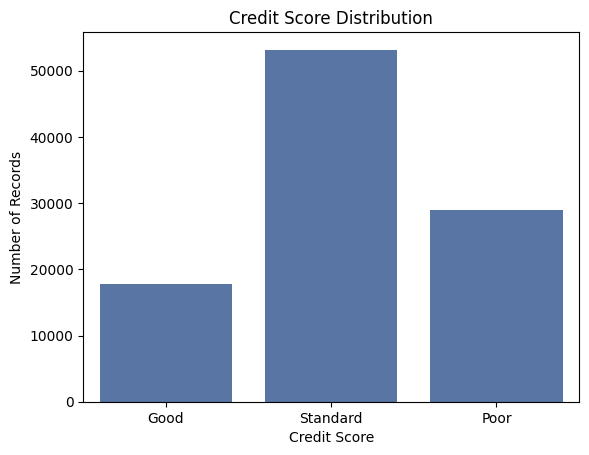

In [274]:
column_name = 'Credit_Score'
user_friendly_name = 'Credit Score'

#Plot Graph
plot_countplot(df_train,column_name,user_friendly_name)


-----------------------------------------------------

Month & Credit_Score Distribution


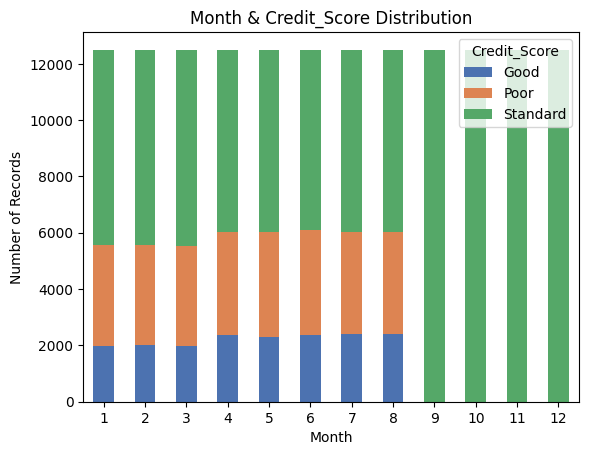

In [275]:
column_name = 'Month'



#Plot Distrbution with Credit_Score
plot_stacked_bar(df,column_name,'Credit_Score')


-----------------------------------------------------

Occupation & Credit_Score Distribution


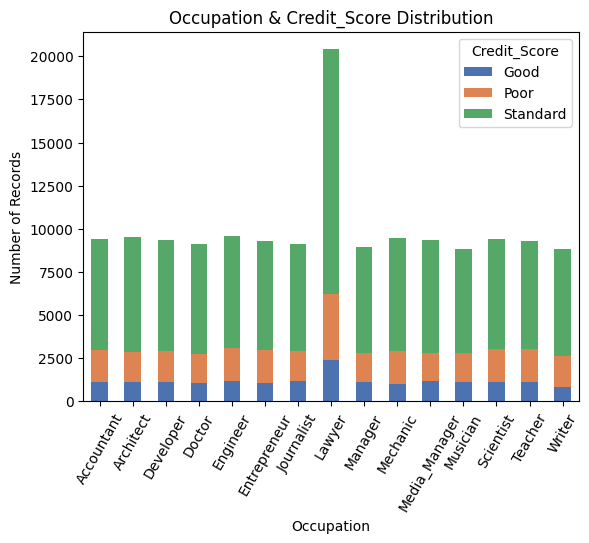

In [276]:
column_name = 'Occupation'
user_friendly_name = 'Occupation'

#Plot Distribution with Credit_Score
plot_stacked_bar(df,column_name,'Credit_Score',rotation=60)


-----------------------------------------------------

Credit_Mix & Credit_Score Distribution


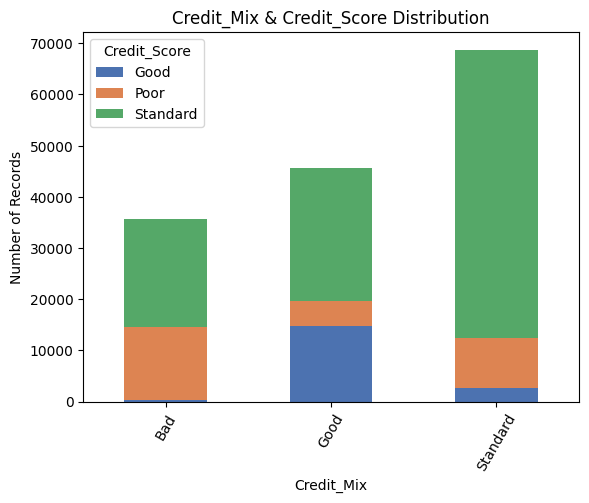

In [277]:
column_name = 'Credit_Mix'

#Plot Distribution with Credit_Score
plot_stacked_bar(df,column_name,'Credit_Score',rotation=60)


-----------------------------------------------------

Payment_of_Min_Amount & Credit_Score Distribution


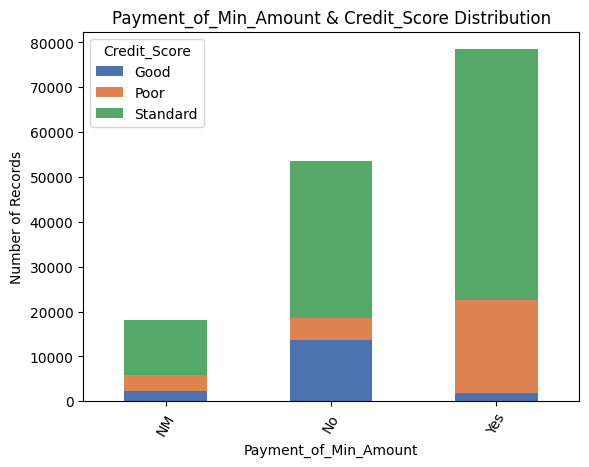

In [278]:
column_name = 'Payment_of_Min_Amount'

#Plot Distribution with Credit_Score
plot_stacked_bar(df,column_name,'Credit_Score',rotation=60)


-----------------------------------------------------

Payment_Behaviour & Credit_Score Distribution


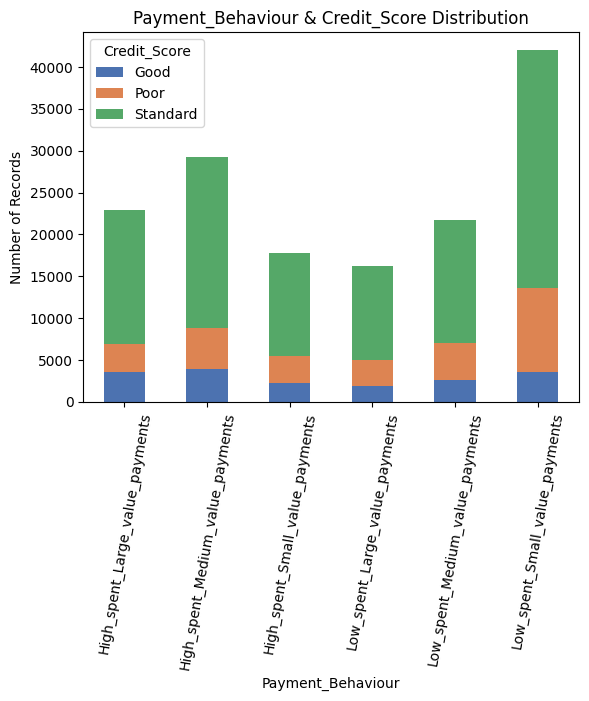

In [279]:
column_name = 'Payment_Behaviour'

#Plot Distribution with Credit_Score
plot_stacked_bar(df,column_name,'Credit_Score',rotation=80)


-----------------------------------------------------

Age Distribution


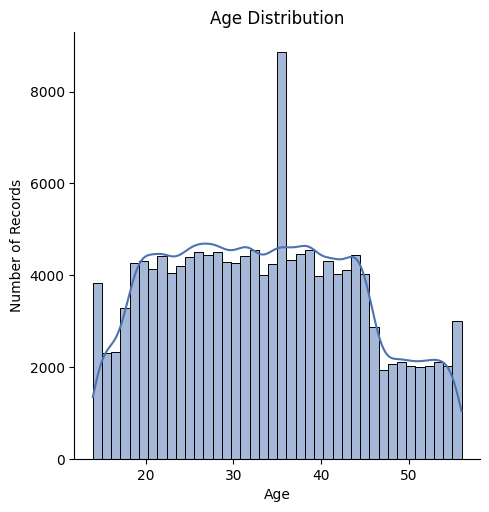

In [280]:
column_name = 'Age'
user_friendly_name = 'Age'

#Plot Graph
plot_displot(df,column_name,user_friendly_name,bins=40)


-----------------------------------------------------

Annual Income Distribution


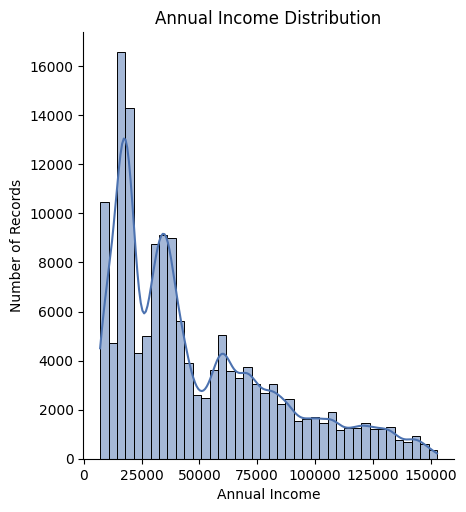

In [281]:
column_name = 'Annual_Income'
user_friendly_name = 'Annual Income'

#Plot Graph
plot_displot(df,column_name,user_friendly_name,bins=40)


-----------------------------------------------------

Monthly Inhand Salary Distribution


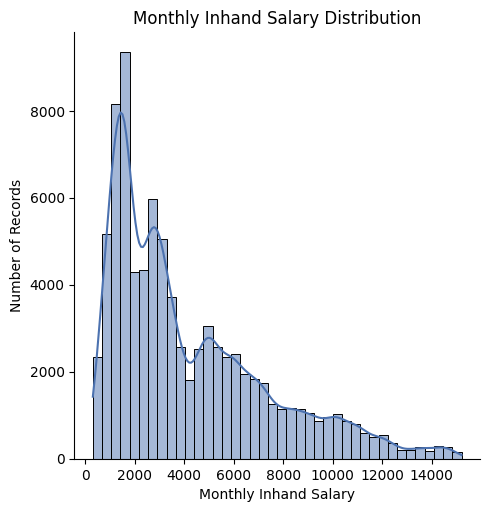

In [282]:
column_name = 'Monthly_Inhand_Salary'
user_friendly_name = 'Monthly Inhand Salary'



#Plot Graph
plot_displot(df_train,column_name,user_friendly_name,bins=40)


-----------------------------------------------------

Number of Bank Accounts Distribution


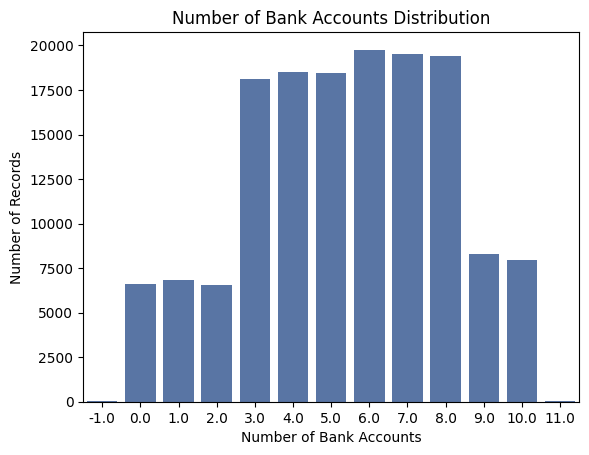

In [283]:
column_name = 'Num_Bank_Accounts'
user_friendly_name = 'Number of Bank Accounts'


#Plot Graph
plot_countplot(df,column_name,user_friendly_name)


-----------------------------------------------------

Number of Credit Card Distribution


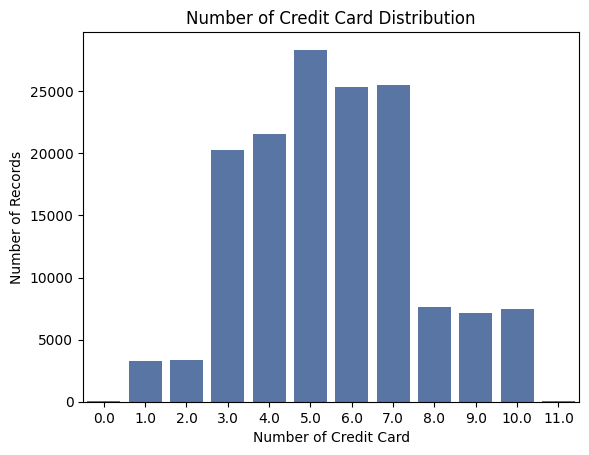

In [284]:
column_name = 'Num_Credit_Card'
user_friendly_name = 'Number of Credit Card'

#Plot Graph
plot_countplot(df,column_name,user_friendly_name)


-----------------------------------------------------

Interest Rate Distribution


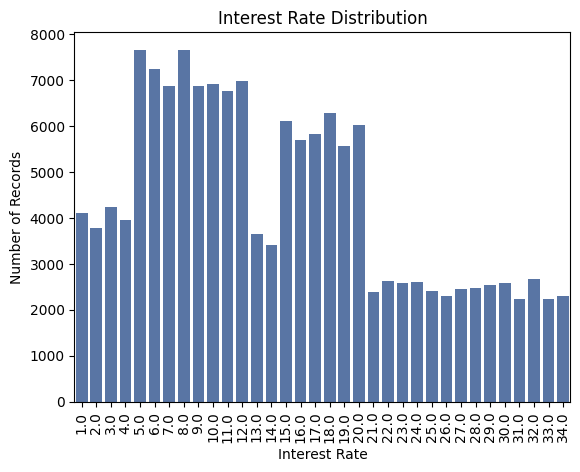

In [285]:
column_name = 'Interest_Rate'
user_friendly_name = 'Interest Rate'

#Plot Graph
plot_countplot(df,column_name,user_friendly_name,rotation=90)


-----------------------------------------------------

Delay from Due Date Distribution


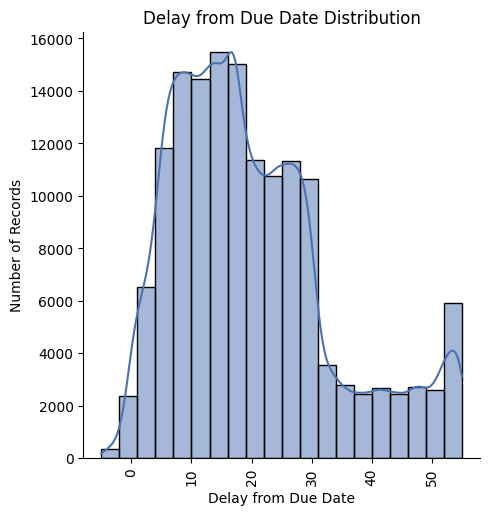

In [286]:
column_name = 'Delay_from_due_date'
user_friendly_name = 'Delay from Due Date'

#Plot Graph
plot_displot(df,column_name,user_friendly_name,rotation=90)


-----------------------------------------------------

Number of Delayed Payment Distribution


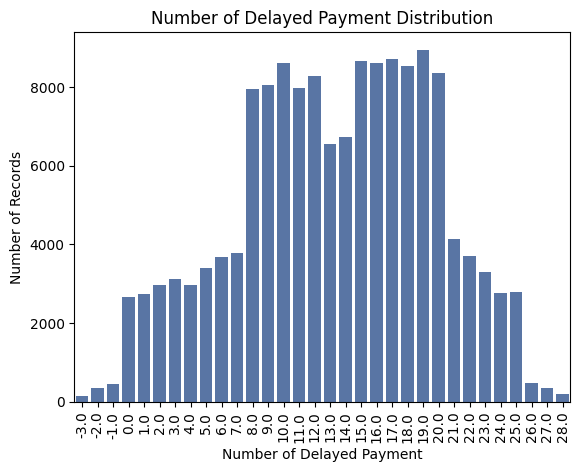

In [287]:
column_name = 'Num_of_Delayed_Payment'
user_friendly_name = 'Number of Delayed Payment'

#Plot Graph
plot_countplot(df,column_name,user_friendly_name,rotation=90)


-----------------------------------------------------

Changed Credit Limit Distribution


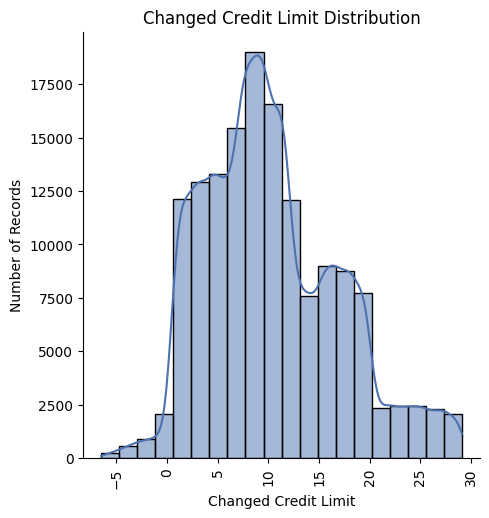

In [288]:
column_name = 'Changed_Credit_Limit'
user_friendly_name = 'Changed Credit Limit'


#Plot Graph
plot_displot(df,column_name,user_friendly_name,rotation=90)


-----------------------------------------------------

Number of Credit Inquiries Distribution


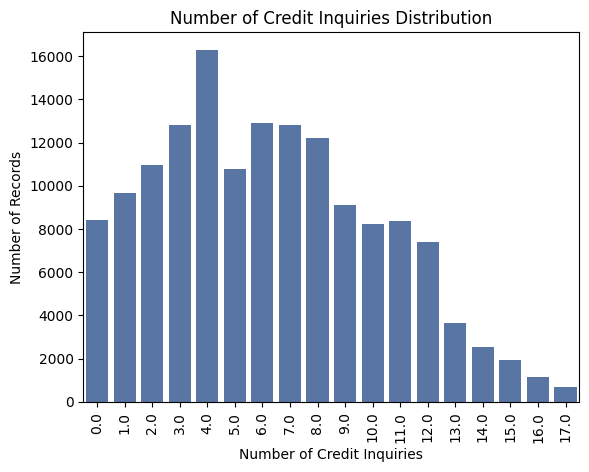

In [289]:
column_name = 'Num_Credit_Inquiries'
user_friendly_name = 'Number of Credit Inquiries'

#Plot Graph
plot_countplot(df,column_name,user_friendly_name,rotation=90)


-----------------------------------------------------

Outstanding Debt Distribution


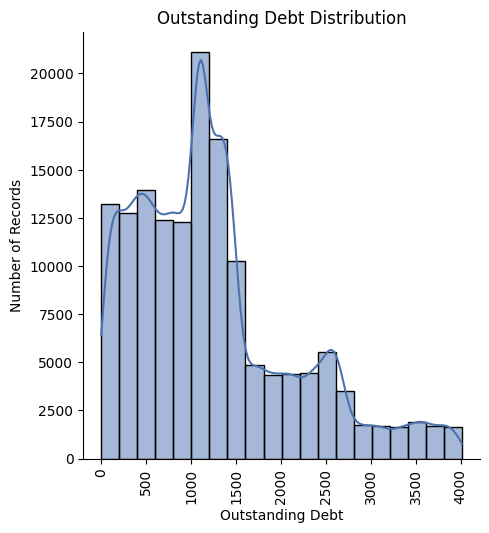

In [290]:
column_name = 'Outstanding_Debt'
user_friendly_name = 'Outstanding Debt'


#Plot Graph
plot_displot(df,column_name,user_friendly_name,rotation=90)


-----------------------------------------------------

Credit Utilization Ratio Distribution


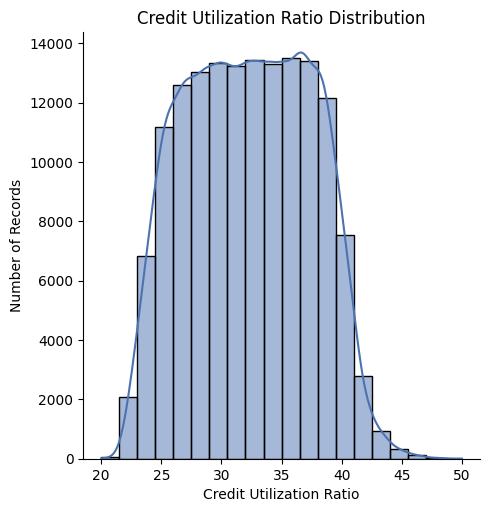

In [291]:
column_name = 'Credit_Utilization_Ratio'
user_friendly_name = 'Credit Utilization Ratio'

#Plot Graph
plot_displot(df,column_name,user_friendly_name)


-----------------------------------------------------

Credit History Age Distribution


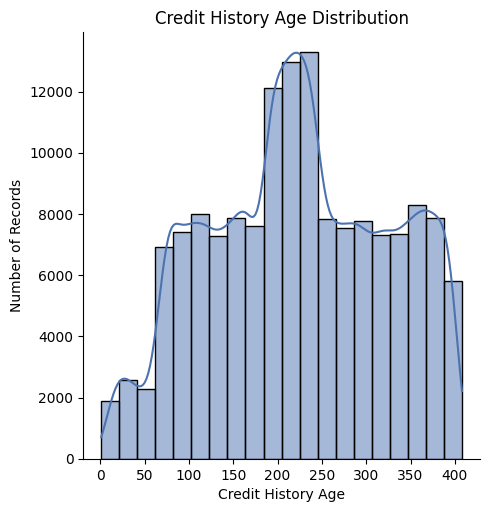

In [292]:
column_name = 'Credit_History_Age'
user_friendly_name = 'Credit History Age'


#Plot Graph
plot_displot(df,column_name,user_friendly_name)


-----------------------------------------------------

Total EMI per month Distribution


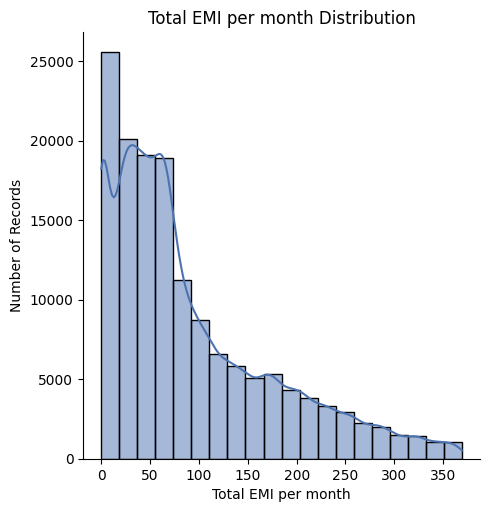

In [293]:
column_name = 'Total_EMI_per_month'
user_friendly_name = 'Total EMI per month'

#Plot Graph
plot_displot(df,column_name,user_friendly_name)


-----------------------------------------------------

Amount invested monthly Distribution


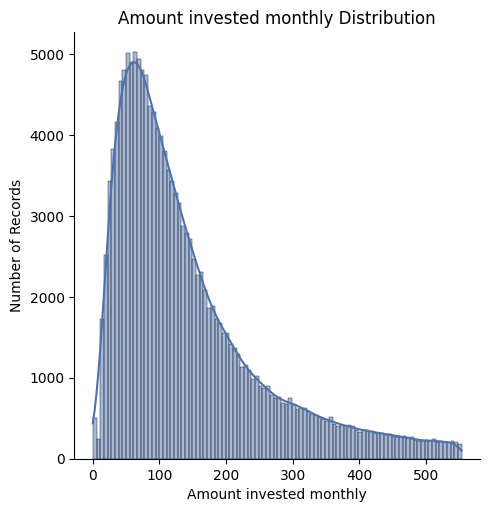

In [294]:
column_name = 'Amount_invested_monthly'
user_friendly_name = 'Amount invested monthly'

#Plot Graph
plot_displot(df,column_name,user_friendly_name,bins=100)


-----------------------------------------------------

Monthly Balance Distribution


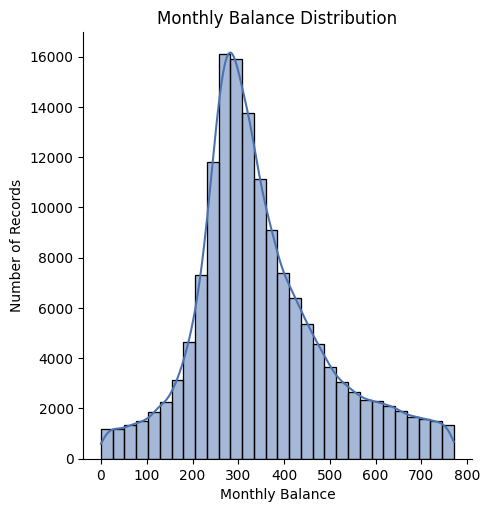

In [295]:
column_name = 'Monthly_Balance'
group_by = 'Customer_ID'
user_friendly_name = 'Monthly Balance'


#Plot Graph
plot_displot(df,column_name,user_friendly_name,bins=30)



-----------------------------------------------------

Number of Loan Distribution


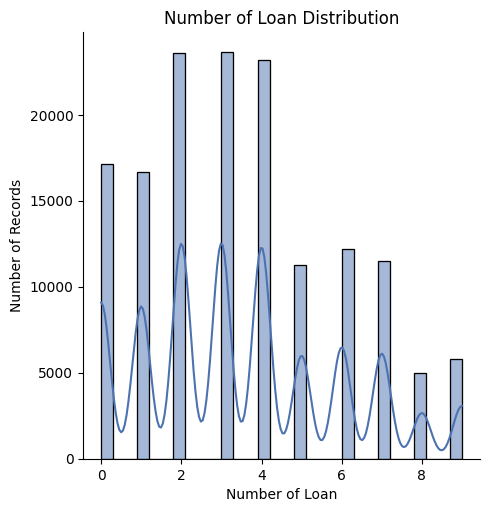

In [296]:
column_name = 'Num_of_Loan'
user_friendly_name = 'Number of Loan'


#Plot Graph
plot_displot(df,column_name,user_friendly_name,bins=30)

# 9.FEATURE CREATION

In [297]:


# 1. Debt-to-Income Ratio
df['Debt_to_Income_Ratio'] = df['Outstanding_Debt'] / df['Annual_Income']
df['Debt_to_Income_Ratio'].fillna(0, inplace=True)  # Handle division by zero

# 2. Delayed Payment Ratio
df['Delayed_Payment_Ratio'] = df['Num_of_Delayed_Payment'] / df['Num_of_Loan']
df['Delayed_Payment_Ratio'].fillna(0, inplace=True)

# 3. Credit Utilization Efficiency
df['Credit_Utilization_Efficiency'] = df['Credit_Utilization_Ratio'] / df['Num_Credit_Card']
df['Credit_Utilization_Efficiency'].fillna(0, inplace=True)

# Display the new features
print("Dataset with New Features:\n")
print(df[['Debt_to_Income_Ratio', 'Delayed_Payment_Ratio', 'Credit_Utilization_Efficiency']].head())


Dataset with New Features:

   Debt_to_Income_Ratio  Delayed_Payment_Ratio  Credit_Utilization_Efficiency
0              0.042376                   1.75                       6.705655
1              0.042376                   1.00                       7.986240
2              0.042376                   1.75                       7.152338
3              0.042376                   1.00                       7.844465
4              0.042376                   1.00                       6.199337


In [298]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance',
       'Credit_Score', 'Debt_to_Income_Ratio', 'Delayed_Payment_Ratio',
       'Credit_Utilization_Efficiency'],
      dtype='object')

In [299]:
df.isnull().sum()

ID                               0
Customer_ID                      0
Month                            0
Name                             0
Age                              0
SSN                              0
Occupation                       0
Annual_Income                    0
Monthly_Inhand_Salary            0
Num_Bank_Accounts                0
Num_Credit_Card                  0
Interest_Rate                    0
Num_of_Loan                      0
Type_of_Loan                     0
Delay_from_due_date              0
Num_of_Delayed_Payment           0
Changed_Credit_Limit             0
Num_Credit_Inquiries             0
Credit_Mix                       0
Outstanding_Debt                 0
Credit_Utilization_Ratio         0
Credit_History_Age               0
Payment_of_Min_Amount            0
Total_EMI_per_month              0
Amount_invested_monthly          0
Payment_Behaviour                0
Monthly_Balance                  0
Credit_Score                     0
Debt_to_Income_Ratio

# 10 .FURTHER PREPROCESSING

In [300]:
df[df['Num_Bank_Accounts']<0]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income_Ratio,Delayed_Payment_Ratio,Credit_Utilization_Efficiency
30330,51128,20266,3,Margaretf,39.0,807035415.0,Engineer,128305.76,10434.146667,-1.0,...,269.0,No,196.587321,230.922386,High_spent_Large_value_payments,120.129276,Standard,0.008976,1.500000,6.764456
30331,51129,20266,4,Margaretf,40.0,807035415.0,Engineer,128305.76,10434.146667,-1.0,...,270.0,No,196.587321,524.304418,Low_spent_Large_value_payments,592.522928,Good,0.008976,3.000000,6.561567
30332,51130,20266,5,Margaretf,40.0,807035415.0,Engineer,128305.76,10434.146667,-1.0,...,271.0,No,196.587321,150.096675,High_spent_Large_value_payments,120.129276,Good,0.008976,4.000000,4.783675
30333,51131,20266,6,Margaretf,40.0,807035415.0,Engineer,128305.76,10434.146667,-1.0,...,272.0,No,196.587321,150.096675,Low_spent_Medium_value_payments,120.129276,Good,0.008976,3.000000,5.801398
30334,51132,20266,7,Margaretf,40.0,807035415.0,Engineer,128305.76,10434.146667,-1.0,...,273.0,No,196.587321,172.992021,High_spent_Large_value_payments,120.129276,Good,0.008976,1.500000,5.867738
30335,51133,20266,8,Margaretf,40.0,807035415.0,Engineer,128305.76,10434.146667,-1.0,...,274.0,No,196.587321,338.672303,High_spent_Medium_value_payments,758.155042,Good,0.008976,3.000000,6.379753
43689,71167,43128,2,Douwe Miedemaz,54.0,300544627.0,Engineer,117851.07,9870.922500,-1.0,...,246.0,No,0.000000,142.319789,High_spent_Large_value_payments,588.947796,Poor,0.005157,inf,6.214351
43690,71168,43128,3,Douwe Miedemaz,54.0,300544627.0,Engineer,117851.07,9870.922500,-1.0,...,247.0,No,0.000000,142.319789,High_spent_Large_value_payments,421.120710,Poor,0.005157,inf,6.985938
43691,71169,43128,4,Douwe Miedemaz,54.0,300544627.0,Engineer,117851.07,9870.922500,-1.0,...,248.0,No,0.000000,467.563923,High_spent_Small_value_payments,421.120710,Poor,0.005157,inf,6.966657
43692,71170,43128,5,Douwe Miedemaz,54.0,300544627.0,Engineer,117851.07,9870.922500,-1.0,...,249.0,No,0.000000,142.319789,High_spent_Large_value_payments,421.120710,Poor,0.005157,inf,7.707430


In [ ]:
df[df['Num_Bank_Accounts']<0]['Customer_ID'].unique()

array([20266, 43128, 17340, 22931], dtype=int64)

In [302]:
df[df['Customer_ID']==22931]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income_Ratio,Delayed_Payment_Ratio,Credit_Utilization_Efficiency
55632,89082,22931,1,Stephensonq,41.0,120482348.0,Developer,30352.11,2317.3425,0.0,...,281.0,No,16.483566,187.641645,Low_spent_Small_value_payments,317.609039,Standard,0.021236,3.0,7.497795
55633,89083,22931,2,Stephensonq,40.0,120482348.0,Developer,30352.11,2317.3425,0.0,...,282.0,No,16.483566,143.322972,High_spent_Small_value_payments,331.927711,Standard,0.021236,3.0,6.046130
55634,89084,22931,3,Stephensonq,40.0,120482348.0,Developer,30352.11,2317.3425,0.0,...,283.0,No,16.483566,60.681956,High_spent_Small_value_payments,414.568728,Standard,0.021236,3.0,7.764486
55635,89085,22931,4,Stephensonq,40.0,120482348.0,Developer,30352.11,2317.3425,0.0,...,284.0,NM,16.483566,54.569799,High_spent_Large_value_payments,400.680884,Standard,0.021236,3.0,7.270379
55636,89086,22931,5,Stephensonq,40.0,120482348.0,Developer,30352.11,2317.3425,-1.0,...,285.0,NM,16.483566,126.665345,Low_spent_Medium_value_payments,368.585338,Standard,0.021236,3.0,6.383000
55637,89087,22931,6,Stephensonq,40.0,120482348.0,Developer,30352.11,2317.3425,-1.0,...,286.0,No,16.483566,54.821327,High_spent_Large_value_payments,400.429357,Standard,0.021236,3.0,7.953315
55638,89088,22931,7,Stephensonq,41.0,120482348.0,Developer,30352.11,2317.3425,-1.0,...,287.0,No,16.483566,64.860838,Low_spent_Small_value_payments,400.389846,Standard,0.021236,3.0,6.643544
55639,89089,22931,8,Stephensonq,41.0,120482348.0,Developer,30352.11,2317.3425,-1.0,...,288.0,No,16.483566,89.622962,High_spent_Medium_value_payments,375.627721,Standard,0.021236,4.0,8.234350
127816,89090,22931,9,Stephensonq,41.0,120482348.0,Developer,30352.11,2317.3425,-1.0,...,289.0,No,16.483566,291.127877,Low_spent_Small_value_payments,214.122807,Standard,0.021236,3.0,8.117093
127817,89091,22931,10,Stephensonq,41.0,120482348.0,Developer,30352.11,2317.3425,-1.0,...,290.0,NM,16.483566,75.160896,High_spent_Medium_value_payments,390.089788,Standard,0.021236,3.0,9.151330


In [303]:
df.loc[df['Num_Bank_Accounts']<0, 'Num_Bank_Accounts'] = 0


In [304]:
df[df['Delay_from_due_date']<0]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income_Ratio,Delayed_Payment_Ratio,Credit_Utilization_Efficiency
1,5635,3392,2,Aaron Maashoh,23.0,821000265.0,Scientist,19114.12,1824.843333,3.0,...,266.0,No,49.574949,118.280222,Low_spent_Large_value_payments,284.629162,Good,0.042376,1.0,7.986240
49,5707,10314,2,Nadiaq,34.0,411510676.0,Lawyer,131313.40,11242.783333,0.0,...,368.0,No,137.644605,86.566388,High_spent_Small_value_payments,547.760457,Good,0.002682,1.0,31.983710
74,5744,47624,3,Jamesj,44.0,366681681.0,Journalist,31370.80,2825.233333,1.0,...,319.0,No,46.616129,140.820696,Low_spent_Medium_value_payments,375.086508,Good,0.013434,0.0,5.174403
78,5748,47624,7,Jamesj,45.0,366681681.0,Journalist,31370.80,2825.233333,1.0,...,323.0,No,46.616129,188.394900,Low_spent_Small_value_payments,337.512304,Good,0.013434,1.0,3.793700
79,5749,47624,8,Jamesj,45.0,366681681.0,Journalist,31370.80,2825.233333,1.0,...,324.0,No,46.616129,252.644827,Low_spent_Small_value_payments,273.262377,Good,0.013434,1.0,6.260842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149220,153302,15772,9,Sybille dee,50.0,619818130.0,Musician,19809.27,1711.772500,5.0,...,365.0,No,14.058627,92.237679,High_spent_Small_value_payments,324.880943,Standard,0.028388,1.0,6.227464
149287,153497,23286,12,Maril,26.0,15208263.0,Accountant,123915.99,10336.332500,3.0,...,208.0,No,156.988147,89.534076,Low_spent_Medium_value_payments,464.721903,Standard,0.011257,0.0,6.342474
149321,153603,4164,10,Maki Shirakip,44.0,261184430.0,Entrepreneur,33441.59,2748.799167,2.0,...,385.0,No,0.000000,371.450586,Low_spent_Small_value_payments,193.429331,Standard,0.004634,inf,7.472797
149687,154697,5692,12,Julien Toyera,32.0,534127952.0,Media_Manager,61465.78,5082.148333,2.0,...,225.0,No,31.650737,196.389540,High_spent_Small_value_payments,540.174557,Standard,0.009906,13.0,10.109271


In [305]:
df[df['Delay_from_due_date']<0]['Customer_ID'].unique()


array([ 3392, 10314, 47624, 49323, 29152,  8970,  6806, 50592, 39249,
       37013, 10251, 35602, 21293, 25414, 33107,  7486,  8086, 34447,
       16606, 34429, 46990, 46716,  1345, 23479, 47754, 34344, 18364,
       48117, 26588, 13075, 37628,  6099, 25714, 35593, 11139,  9918,
       34581, 11176,  3111, 50221, 24967,  2341, 39348, 31884, 43042,
       45474, 45380, 17203, 38196, 20457, 39199,  5636, 48972, 34701,
       29149, 47242, 41376, 49612, 27608, 18007, 34215, 39945, 35520,
       45442, 25254,  1933, 46251, 30833,  7980, 14398, 42740, 20552,
       14909,  7702, 31516, 33829, 49400, 24126, 10147,  2738,  8668,
       38566, 38293, 44761, 30315, 21183,  9085, 23713, 49882, 12828,
        7344,  5703, 31079, 29088, 28707, 22029, 28014, 42133, 30982,
       26811,  2227,  6345, 17242, 41487,  1645, 36766, 38938, 42510,
       50037, 31866, 14850, 19248, 18498, 21096, 20132, 47316, 11167,
       49593, 44503, 43834, 43059, 18461, 13949, 22966, 35079, 10548,
       44315,  8292,

In [306]:
df[df['Customer_ID']==48234].iloc[:,0:15]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date
93536,145938,48234,1,Andreasz,51.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,2.0
93537,145939,48234,2,Andreasz,51.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,2.0
93538,145940,48234,3,Andreasz,51.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,2.0
93539,145941,48234,4,Andreasz,51.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,2.0
93540,145942,48234,5,Andreasz,51.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,2.0
93541,145943,48234,6,Andreasz,51.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,-2.0
93542,145944,48234,7,Andreasz,51.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,2.0
93543,145945,48234,8,Andreasz,52.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,-2.0
146768,145946,48234,9,Andreasz,52.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,2.0
146769,145947,48234,10,Andreasz,52.0,669332894.0,Media_Manager,36425.96,3035.655833,2.0,4.0,12.0,0.0,No Data,2.0


In [307]:
df.loc[df['Delay_from_due_date']<0, 'Delay_from_due_date'] = None


In [308]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Delay_from_due_date')



Existing Min, Max Values for Delay_from_due_date:
min     0.0
max    55.0
Name: Delay_from_due_date, dtype: float64
Outliers: 4549

IQR-Based Range for Delay_from_due_date: [-15.5, 52.5]


Before Cleaning Example Delay_from_due_date:

[48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 50.0, 48.0, 53.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 16.0, 20.0, 19.0, 15.0, 19.0]
[25.0, 28.0, 22.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 21.0, 26.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 18.0, 21.0, 19.0]
[15.0, 15.0, 20.0, 16.0, 20.0, 20.0, 20.0, 24.0, 25.0, 20.0, 20.0, 20.0]
Outliers: 4549

Updated Min, Max Values for Delay_from_due_date:
min     0.0
max    52.0
Name: Delay_from_due_date, dtype: float64

After Cleaning Example Delay_from_due_date:

[48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 48.0, 50.0, 48.0, 48.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 19.0, 16.0, 20.0, 19.0, 15.0, 19.0]
[25.0, 28.0, 22.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 26.0, 21.0, 26.0]
[19

In [309]:
df[df['Num_of_Delayed_Payment']<0]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income_Ratio,Delayed_Payment_Ratio,Credit_Utilization_Efficiency
10,5648,8625,3,Rick Rothackerj,28.0,4075839.0,Teacher,34847.840,3037.986667,2.0,...,321.0,No,18.816215,58.515976,High_spent_Large_value_payments,466.466476,Standard,0.017362,-1.00,8.306238
698,6680,29152,3,Aruna Viswanathau,28.0,330960638.0,Mechanic,15398.950,1548.245833,1.0,...,341.0,NM,34.813970,47.607470,High_spent_Medium_value_payments,322.403143,Standard,0.022329,-0.25,4.784920
1253,7511,12757,6,Mutikanit,49.0,325078725.0,Doctor,15488.885,1273.740417,0.0,...,307.0,NM,0.000000,97.705452,Low_spent_Small_value_payments,319.668590,Standard,0.083130,-inf,7.700270
1561,7975,45940,2,enu,32.0,946089738.0,Architect,30922.280,2494.856667,1.0,...,256.0,No,30.338204,159.523585,Low_spent_Large_value_payments,329.623877,Poor,0.030966,-1.00,7.827185
2167,8881,10251,8,orv,27.0,434178443.0,Accountant,34841.870,3025.489167,1.0,...,374.0,No,33.366098,174.874086,Low_spent_Medium_value_payments,374.308732,Standard,0.004077,-0.50,5.478740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149243,153365,12580,12,Philz,54.0,921270890.0,Journalist,43502.680,3733.223333,0.0,...,318.0,No,32.032328,503.575571,Low_spent_Small_value_payments,127.714435,Standard,0.019818,-1.00,4.040471
149285,153495,23286,10,Maril,26.0,15208263.0,Accountant,123915.990,10336.332500,3.0,...,206.0,NM,156.988147,260.694372,High_spent_Large_value_payments,418.078710,Standard,0.011257,-0.50,6.055532
149288,153506,40156,9,Mostafavin,24.0,187132907.0,Scientist,16937.425,1162.452083,4.0,...,265.0,No,7.247943,100.919000,Low_spent_Medium_value_payments,288.078266,Standard,0.009893,-3.00,5.440604
149289,153507,40156,10,Mostafavin,24.0,187132907.0,Scientist,16937.425,1162.452083,4.0,...,266.0,No,7.247943,123.801030,Low_spent_Small_value_payments,275.196236,Standard,0.009893,-1.00,6.775062


In [310]:

df[df['Num_of_Delayed_Payment']<0]['Customer_ID'].unique()


array([ 8625, 29152, 12757, 45940, 10251,  3333,  3929, 21293,  4426,
       25414, 16167, 43066, 21322, 10123, 35188, 26218, 26418, 28910,
       32265, 11773, 47754, 49199, 14290, 20016, 19075, 49507, 13075,
       48148, 45080,  4477, 37628, 35058, 19758, 17488, 11148, 25321,
       13654, 36050, 33615,  9918, 11176,  4829, 48209, 34440, 44404,
       47715, 10269, 39909, 26631, 31123, 39182, 13666,  9624, 48972,
        3559, 34701, 15614, 47448, 19145, 25434, 33042,  1604, 48331,
       11426, 13888, 41376, 48578, 44043,  5136, 27608,  2221, 29037,
       35859, 18007, 45442, 48633, 16890, 43386, 23420, 25655,  2170,
        4483,  5754, 32772,  8778,  3626, 26972,  8668, 15729, 37190,
       10351, 17846, 38293, 20868, 30410, 50983,  5893, 11542, 45048,
       21518, 35124, 29088, 22029, 45052, 46467, 39733, 21719, 11988,
       44699, 42964, 37741, 36766, 13582, 39656, 31866, 16818, 23184,
        5843, 50902, 20553, 35440, 44118, 21037, 32270, 44792, 44787,
       24955, 43895,

In [311]:
df[df['Customer_ID']==8625].iloc[:,0:20]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt
8,5646,8625,1,Rick Rothackerj,28.0,4075839.0,Lawyer,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,4.0,5.42,2.0,Good,605.03
9,5647,8625,2,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,7.0,1.0,7.42,2.0,Good,605.03
10,5648,8625,3,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,-1.0,5.42,2.0,Good,605.03
11,5649,8625,4,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,3.0,5.42,2.0,Good,605.03
12,5650,8625,5,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,1.0,6.42,2.0,Good,605.03
13,5651,8625,6,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,0.0,5.42,2.0,Good,605.03
14,5652,8625,7,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,4.0,5.42,2.0,Good,605.03
15,5653,8625,8,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,4.0,5.42,2.0,Good,605.03
100004,5654,8625,9,Rick Rothackerj,28.0,4075839.0,Lawyer,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,1.0,5.42,5.0,Good,605.03
100005,5655,8625,10,Rick Rothackerj,28.0,4075839.0,Teacher,34847.84,3037.986667,2.0,4.0,6.0,1.0,Credit-Builder Loan,3.0,3.0,5.42,5.0,Good,605.03


In [312]:
df.loc[df['Num_of_Delayed_Payment']<0, 'Num_of_Delayed_Payment'] = None



In [313]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Num_of_Delayed_Payment')


Existing Min, Max Values for Num_of_Delayed_Payment:
min     0.0
max    28.0
Name: Num_of_Delayed_Payment, dtype: float64
Outliers: 0

IQR-Based Range for Num_of_Delayed_Payment: [-4.5, 31.5]


Before Cleaning Example Num_of_Delayed_Payment:

[10.0, 12.0, 12.0, 13.0, 12.0, 12.0, 11.0, 12.0, 12.0, 12.0, 11.0, 12.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 21.0, 20.0, 19.0, 19.0, 18.0, 19.0, 20.0]
[11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 13.0, 12.0, 11.0, 13.0, 11.0]
[18.0, 18.0, 18.0, 18.0, 18.0, 18.0, 20.0, 18.0, 18.0, 18.0, 18.0, 18.0]
[17.0, 16.0, 14.0, 14.0, 17.0, 14.0, 11.0, 14.0, 14.0, 14.0, 17.0, 12.0]
Outliers: 0

Updated Min, Max Values for Num_of_Delayed_Payment:
min     0.0
max    28.0
Name: Num_of_Delayed_Payment, dtype: float64

After Cleaning Example Num_of_Delayed_Payment:

[10.0, 12.0, 12.0, 13.0, 12.0, 12.0, 11.0, 12.0, 12.0, 12.0, 11.0, 12.0]
[19.0, 19.0, 19.0, 19.0, 19.0, 21.0, 20.0, 19.0, 19.0, 18.0, 19.0, 20.0]
[11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 11.0, 13.0, 12.0, 11.0, 1

In [314]:
df[df['Monthly_Balance']<0]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income_Ratio,Delayed_Payment_Ratio,Credit_Utilization_Efficiency


In [315]:
df[df['Monthly_Balance']<0]['Customer_ID'].unique()


array([], dtype=int64)

In [316]:
df[df['Customer_ID']==23184]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income_Ratio,Delayed_Payment_Ratio,Credit_Utilization_Efficiency
26176,44898,23184,1,Scuffhamq,45.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,380.0,No,34.496445,103.349985,High_spent_Medium_value_payments,367.289486,Standard,0.030846,-1.0,9.179608
26177,44899,23184,2,Scuffhamq,45.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,381.0,No,34.496445,198.611513,Low_spent_Large_value_payments,241.925907,Good,0.030846,0.0,9.549519
26178,44900,23184,3,Scuffhamq,45.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,382.0,No,34.496445,211.196133,Low_spent_Small_value_payments,299.443338,Good,0.030846,-0.5,7.396658
26179,44901,23184,4,Scuffhamq,45.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,383.0,No,34.496445,24.033229,Low_spent_Small_value_payments,269.745509,Good,0.030846,1.5,8.314142
26180,44902,23184,5,Scuffhamq,45.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,384.0,No,34.496445,27.408165,High_spent_Medium_value_payments,443.231307,Good,0.030846,-1.0,7.472916
26181,44903,23184,6,Scuffhamq,45.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,385.0,No,34.496445,81.238820,Low_spent_Medium_value_payments,419.400651,Good,0.030846,0.5,10.130770
26182,44904,23184,7,Scuffhamq,45.0,264531943.0,Lawyer,29728.31,2551.359167,3.0,...,386.0,No,34.496445,203.985506,Low_spent_Medium_value_payments,296.653965,Standard,0.030846,0.5,9.827615
26183,44905,23184,8,Scuffhamq,46.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,387.0,No,34.496445,268.713564,Low_spent_Small_value_payments,241.925907,Good,0.030846,-1.0,9.489738
113088,44906,23184,9,Scuffhamq,46.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,388.0,No,34.496445,47.255861,High_spent_Large_value_payments,413.383610,Standard,0.030846,0.5,9.088385
113089,44907,23184,10,Scuffhamq,46.0,264531943.0,Engineer,29728.31,2551.359167,3.0,...,389.0,No,34.496445,24.033229,High_spent_Large_value_payments,436.606242,Standard,0.030846,0.5,9.048590


In [317]:
df.loc[df['Monthly_Balance']<0, 'Monthly_Balance'] = None


In [318]:
Numeric_Wrong_Values_Reassign_Group_Min_Max(df, 'Customer_ID', 'Monthly_Balance')


Existing Min, Max Values for Monthly_Balance:
min      0.007760
max    770.768524
Name: Monthly_Balance, dtype: float64
Outliers: 6837

IQR-Based Range for Monthly_Balance: [14.504519423924961, 667.115505570821]


Before Cleaning Example Monthly_Balance:

[310.39167595729333, 295.61432104073225, 333.9600295968694, 309.1977625633686, 323.9664999631732, 334.864456417663, 280.04409663983637, 328.97449591530835, 279.14863869481445, 306.61186979020056, 301.87706575887506, 227.25690402118008]
[323.5550777151861, 309.6085947906515, 265.4874646531188, 291.11606352715245, 245.61898478406326, 239.46481499922072, 334.61958840607645, 275.3861034815317, 279.58867604354555, 318.4767883518287, 260.7342254927612, 307.57591763672826]
[406.62288544232047, 350.39351957834924, 218.30384271186168, 354.63462349002145, 441.30551404075095, 420.04620414440666, 337.6532108572321, 370.2991478574313, 474.5734332336703, 439.0620993738886, 203.58056486748768, 459.8749140303517]
[581.4298200072883, 573.828975420695

In [319]:
df[df['Amount_invested_monthly']>=10000]


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income_Ratio,Delayed_Payment_Ratio,Credit_Utilization_Efficiency


In [320]:
df[df['Amount_invested_monthly']>=10000]['Customer_ID'].unique()



array([], dtype=int64)

In [321]:
df[df['Customer_ID']==44897]

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score,Debt_to_Income_Ratio,Delayed_Payment_Ratio,Credit_Utilization_Efficiency
99976,155598,44897,1,Chris Wickhamm,49.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,357.0,No,84.205949,223.875018,Low_spent_Small_value_payments,291.619866,Good,0.016689,4.000000,9.770206
99977,155599,44897,2,Chris Wickhamm,49.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,358.0,No,84.205949,70.869970,High_spent_Large_value_payments,394.624914,Good,0.016689,4.000000,8.200858
99978,155600,44897,3,Chris Wickhamm,49.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,359.0,No,84.205949,125.956592,Low_spent_Medium_value_payments,379.538292,Good,0.016689,3.666667,6.135127
99979,155601,44897,4,Chris Wickhamm,49.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,360.0,NM,84.205949,215.486386,Low_spent_Small_value_payments,300.008498,Good,0.016689,4.000000,9.244752
99980,155602,44897,5,Chris Wickhamm,49.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,361.0,No,84.205949,78.497727,Low_spent_Small_value_payments,396.997157,Standard,0.016689,4.000000,6.873816
99981,155603,44897,6,Chris Wickhamm,50.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,362.0,NM,84.205949,147.339908,Low_spent_Small_value_payments,368.154976,Good,0.016689,4.000000,9.438253
99982,155604,44897,7,Chris Wickhamm,50.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,363.0,No,84.205949,82.825572,Low_spent_Small_value_payments,412.669312,Good,0.016689,4.333333,9.712670
99983,155605,44897,8,Chris Wickhamm,50.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,364.0,No,84.205949,42.935566,High_spent_Medium_value_payments,432.559318,Good,0.016689,3.000000,9.825245
149988,155606,44897,9,Chris Wickhamm,50.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,365.0,No,84.205949,165.115322,Low_spent_Small_value_payments,350.379562,Standard,0.016689,4.000000,8.185216
149989,155607,44897,10,Chris Wickhamm,50.0,133167738.0,Writer,37188.1,3097.008333,1.0,...,366.0,No,84.205949,42.935566,Low_spent_Large_value_payments,270.754039,Standard,0.016689,4.000000,5.996505


<Axes: >

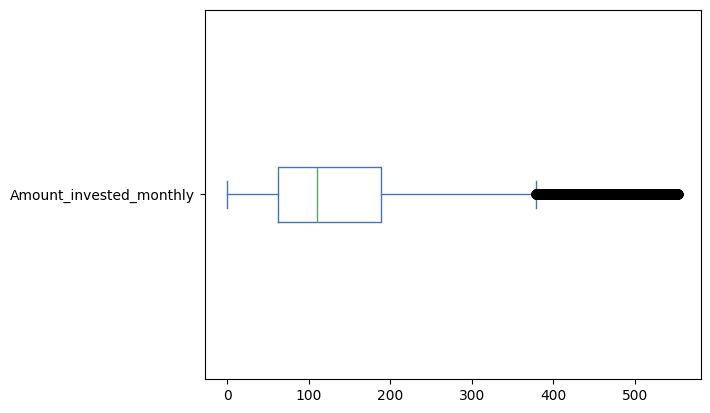

In [322]:
df['Amount_invested_monthly'].plot(kind='box', vert=0)

In [323]:
df.loc[df['Amount_invested_monthly']>=10000, 'Amount_invested_monthly'] = None



<Axes: >

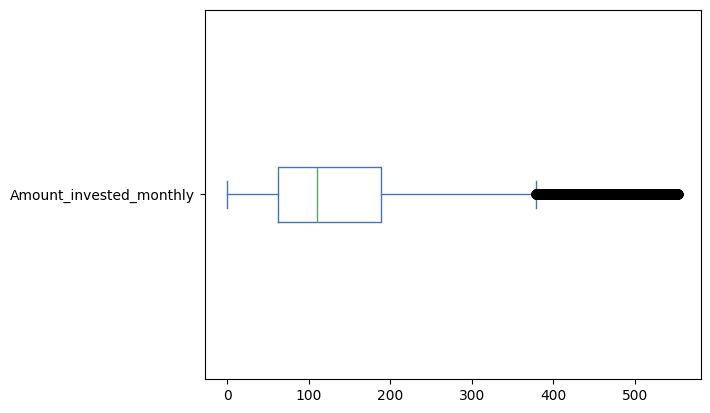

In [324]:
df['Amount_invested_monthly'].plot(kind='box', vert=0)

In [325]:
# fill group Mode
df['Amount_invested_monthly'] = df.groupby('Customer_ID')['Amount_invested_monthly'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.NaN)

### DROPPING UNNECESSARY COLUMNS

In [326]:
# Step 1: Drop Unnecessary Columns
columns_to_drop = ['ID', 'Customer_ID', 'Name', 'SSN']
df = df.drop(columns=columns_to_drop)

# 11. DATA TRANFORMATION

# 11A.HANDLING IMBALANCE IN TARGET

In [327]:

# Define the feature columns and target column
X = df.drop(columns=['Credit_Score'])  # Features
y = df['Credit_Score']  # Target

# Initialize the random oversampler
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)

# Apply oversampling
X_resampled, y_resampled = ros.fit_resample(X, y)

# Verify the balance of classes after oversampling
print(f"Original class distribution: \n{y.value_counts()}")
print(f"Resampled class distribution: \n{y_resampled.value_counts()}")


Original class distribution: 
Credit_Score
Standard    103174
Poor         28998
Good         17828
Name: count, dtype: int64
Resampled class distribution: 
Credit_Score
Good        103174
Standard    103174
Poor        103174
Name: count, dtype: int64


In [328]:


# Assuming your dataset is in 'df'
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# Display numerical columns
print(numerical_columns)


Index(['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio',
       'Credit_History_Age', 'Total_EMI_per_month', 'Amount_invested_monthly',
       'Monthly_Balance', 'Debt_to_Income_Ratio', 'Delayed_Payment_Ratio',
       'Credit_Utilization_Efficiency'],
      dtype='object')


# 11B.LABEL ENCODING

In [329]:
# Identify categorical columns
categorical_columns = ['Credit_Mix', 'Payment_of_Min_Amount', 'Type_of_Loan', 'Payment_Behaviour','Credit_Score']

# Apply Label Encoding
label_encoder = LabelEncoder()
for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])


# 12 .FEATURE SELECTION 

In [330]:

# Step 1: Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# Step 2: Handle missing values
numeric_df = numeric_df.fillna(numeric_df.mean())

# Step 3: Compute correlation matrix
correlation_matrix = numeric_df.corr()

# Step 4: Correlation with the target variable
correlation_with_target = correlation_matrix['Credit_Score'].sort_values(ascending=False)
print(correlation_with_target)



Credit_Score                     1.000000
Month                            0.340799
Credit_Mix                       0.168711
Num_of_Delayed_Payment           0.148263
Changed_Credit_Limit             0.139222
Payment_of_Min_Amount            0.132094
Num_Bank_Accounts                0.130171
Num_Credit_Inquiries             0.123977
Delayed_Payment_Ratio            0.092478
Interest_Rate                    0.088853
Delay_from_due_date              0.087826
Num_Credit_Card                  0.083125
Num_of_Loan                      0.047009
Payment_Behaviour                0.017270
Debt_to_Income_Ratio             0.015146
Outstanding_Debt                 0.011351
Total_EMI_per_month              0.002306
Type_of_Loan                    -0.004680
Credit_Utilization_Ratio        -0.010778
Monthly_Balance                 -0.011295
Age                             -0.033854
Monthly_Inhand_Salary           -0.036975
Annual_Income                   -0.038222
Amount_invested_monthly         -0

In [331]:
# Prepare the data
X_cat = df[categorical_columns]
y = df['Credit_Score']

# Apply Chi-Square Test
chi2_vals, p_vals = chi2(X_cat, y)

# Display results
chi2_results = pd.DataFrame({
    'Feature': categorical_columns,
    'Chi2_Stat': chi2_vals,
    'P_Value': p_vals
})

# Sort by p-value to find significant features
print(chi2_results.sort_values(by='P_Value'))


                 Feature     Chi2_Stat  P_Value
0             Credit_Mix   4680.817214      0.0
1  Payment_of_Min_Amount   3032.514637      0.0
2           Type_of_Loan  12681.571209      0.0
3      Payment_Behaviour   1792.043795      0.0
4           Credit_Score  46171.850314      0.0


In [332]:


# Step 1: Select numerical columns for feature matrix
X_num = df.select_dtypes(include=[np.number])


# Clean X_num (numerical features)
X_num = X_num.replace([np.inf, -np.inf], np.nan)  # Replace inf values with NaN
X_num = X_num.fillna(X_num.median())  # Fill NaN with median (or use other strategies)

# Ensure target variable y is clean
y = y.replace([np.inf, -np.inf], np.nan).dropna()

# Validate consistency between X_num and y
X_num = X_num.loc[y.index]  # Align indices of X_num with y

# Apply F-test (ANOVA)
f_values, p_values = f_classif(X_num, y)

# Display the results
f_test_results = pd.DataFrame({
    'Feature': X_num.columns,
    'F_Stat': f_values,
    'P_Value': p_values
}).sort_values(by='F_Stat', ascending=False)

print(f_test_results)

                          Feature        F_Stat        P_Value
22                   Credit_Score           inf   0.000000e+00
6                   Interest_Rate  1.383850e+04   0.000000e+00
0                           Month  1.230809e+04   0.000000e+00
12           Num_Credit_Inquiries  9.458174e+03   0.000000e+00
5                 Num_Credit_Card  9.101484e+03   0.000000e+00
9             Delay_from_due_date  9.075771e+03   0.000000e+00
14               Outstanding_Debt  9.035899e+03   0.000000e+00
4               Num_Bank_Accounts  8.727267e+03   0.000000e+00
16             Credit_History_Age  8.471575e+03   0.000000e+00
10         Num_of_Delayed_Payment  8.336853e+03   0.000000e+00
25  Credit_Utilization_Efficiency  7.385730e+03   0.000000e+00
7                     Num_of_Loan  6.963596e+03   0.000000e+00
23           Debt_to_Income_Ratio  5.288866e+03   0.000000e+00
17          Payment_of_Min_Amount  4.704331e+03   0.000000e+00
13                     Credit_Mix  4.689084e+03   0.000

In [333]:

# Select only the highly correlated features
selected_features = [
    'Credit_Mix', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
    'Payment_of_Min_Amount', 'Num_Bank_Accounts', 'Num_Credit_Inquiries',
    'Delay_from_due_date', 'Interest_Rate', 'Credit_History_Age',
    'Outstanding_Debt', 'Credit_Utilization_Efficiency', 'Type_of_Loan', 
    'Payment_Behaviour', 'Credit_Score'  # Include target variable
]

df = df[selected_features]

# 13. NORMALIZATION

In [334]:
# Normalize numerical features
numerical_columns = [
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Bank_Accounts',
    'Num_Credit_Inquiries', 'Delay_from_due_date', 'Interest_Rate', 
    'Credit_History_Age', 'Outstanding_Debt', 'Credit_Utilization_Efficiency'
]
 



In [335]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Example numerical columns
numerical_columns = [
    'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Bank_Accounts',
    'Num_Credit_Inquiries', 'Delay_from_due_date', 'Interest_Rate', 
    'Credit_History_Age', 'Outstanding_Debt', 'Credit_Utilization_Efficiency'
]

# Step 1: Replace infinite values with NaN
df[numerical_columns] = df[numerical_columns].replace([np.inf, -np.inf], np.nan)

# Step 2: Fill missing values (e.g., with median)
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

# Step 3: Apply MinMaxScaler
scaler = MinMaxScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])

# Step 4: Verify transformation
print(df[numerical_columns].head())


   Num_of_Delayed_Payment  Changed_Credit_Limit  Num_Bank_Accounts  \
0                0.250000              0.499157           0.272727   
1                0.142857              0.499157           0.272727   
2                0.250000              0.499157           0.272727   
3                0.142857              0.358628           0.272727   
4                0.142857              0.499157           0.272727   

   Num_Credit_Inquiries  Delay_from_due_date  Interest_Rate  \
0              0.235294             0.057692       0.060606   
1              0.235294             0.057692       0.060606   
2              0.235294             0.057692       0.060606   
3              0.235294             0.096154       0.060606   
4              0.235294             0.115385       0.060606   

   Credit_History_Age  Outstanding_Debt  Credit_Utilization_Efficiency  
0            0.648649          0.201725                       0.098773  
1            0.651106          0.201725               

# 14.SPLITING OF  DATA INTO TRAIN TEST 

In [336]:
# Define features and target variable
X = df.drop('Credit_Score', axis=1)
y = df['Credit_Score']

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 15.MODEL BUILDING  AND EVALUATION

In [337]:
# Method to evaluate the performance of the model
def evaluate_model(y_test,y_pred):
    print("Classification Report")
    print(classification_report(y_test, y_pred))
    
    print("\n---------------------------------------------\n")
    # Compute confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Create a heatmap of the confusion matrix using Seaborn
    sns.heatmap(cm, annot=True, cmap='Greens',fmt='.0f')

    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')

    plt.show()


In [338]:
# List of classifiers to test
classifiers = [
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Gaussion NB',GaussianNB()),
    ('XGB',xgb.XGBClassifier())
]

# Iterate over each classifier and evaluate performance
for clf_name, clf in classifiers:
    # Perform cross-validation
    scores = cross_val_score(clf, X_train, y_train, cv=5, scoring='accuracy')
    
    # Calculate average performance metrics
    avg_accuracy = scores.mean()
    avg_precision = cross_val_score(clf, X_train, y_train, cv=5, scoring='precision_macro').mean()
    avg_recall = cross_val_score(clf, X_train, y_train, cv=5, scoring='recall_macro').mean()
    
    # Print the performance metrics
    print(f'Classifier: {clf_name}')
    print(f'Average Accuracy: {avg_accuracy:.4f}')
    print(f'Average Precision: {avg_precision:.4f}')
    print(f'Average Recall: {avg_recall:.4f}')
    print('-----------------------')


Classifier: KNN
Average Accuracy: 0.6671
Average Precision: 0.5364
Average Recall: 0.5091
-----------------------
Classifier: Gaussion NB
Average Accuracy: 0.5693
Average Precision: 0.5291
Average Recall: 0.6448
-----------------------
Classifier: XGB
Average Accuracy: 0.7310
Average Precision: 0.6533
Average Recall: 0.5420
-----------------------


Training and Evaluating Logistic Regression...

Accuracy: 0.6619

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.00      0.00      3608
           1       0.40      0.24      0.30      5867
           2       0.70      0.90      0.78     20525

    accuracy                           0.66     30000
   macro avg       0.57      0.38      0.36     30000
weighted avg       0.63      0.66      0.60     30000



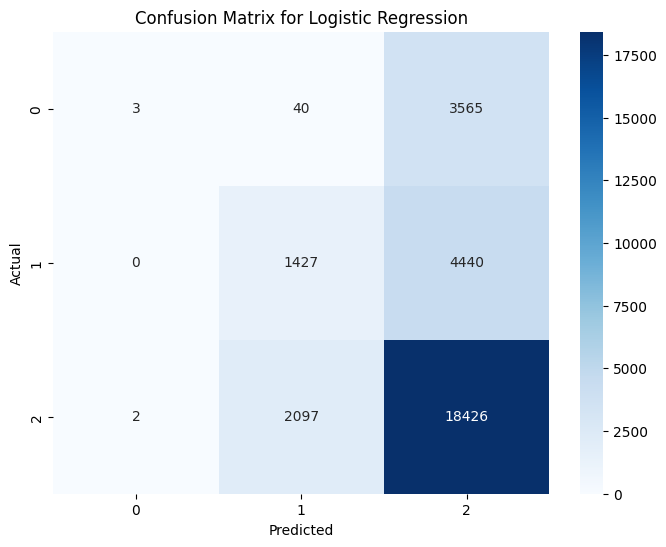

Training and Evaluating Decision Tree...

Accuracy: 0.7111

Classification Report:

              precision    recall  f1-score   support

           0       0.48      0.50      0.49      3608
           1       0.56      0.58      0.57      5867
           2       0.80      0.79      0.79     20525

    accuracy                           0.71     30000
   macro avg       0.61      0.62      0.62     30000
weighted avg       0.71      0.71      0.71     30000



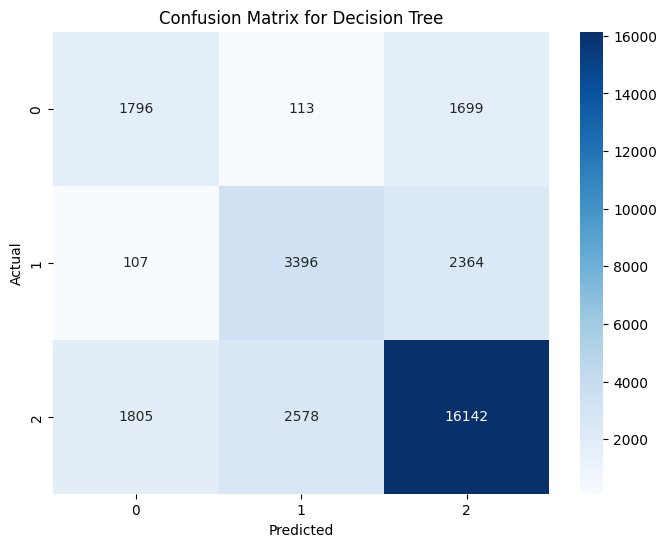

Training and Evaluating Random Forest...

Accuracy: 0.7694

Classification Report:

              precision    recall  f1-score   support

           0       0.67      0.48      0.56      3608
           1       0.66      0.58      0.62      5867
           2       0.81      0.87      0.84     20525

    accuracy                           0.77     30000
   macro avg       0.71      0.65      0.67     30000
weighted avg       0.76      0.77      0.76     30000



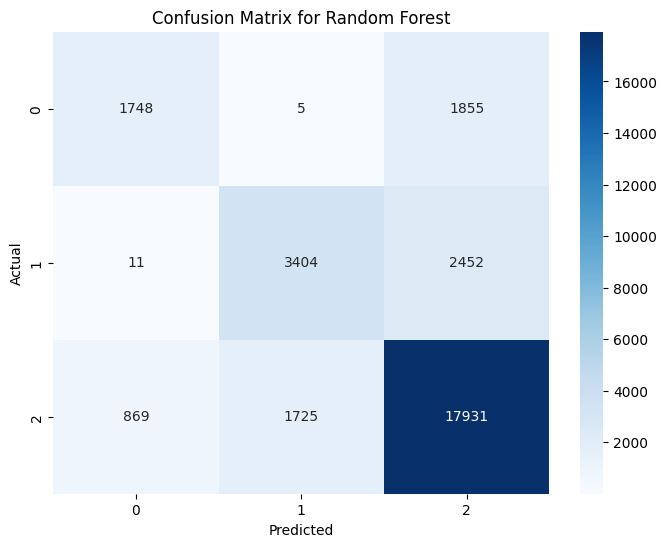

Training and Evaluating Gradient Boosting...

Accuracy: 0.7144

Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.17      0.27      3608
           1       0.58      0.41      0.48      5867
           2       0.74      0.90      0.81     20525

    accuracy                           0.71     30000
   macro avg       0.64      0.49      0.52     30000
weighted avg       0.69      0.71      0.68     30000



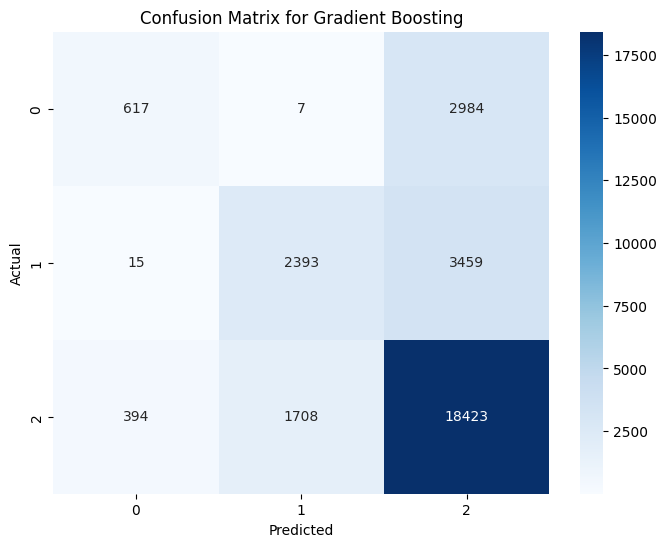

In [341]:
# Dictionary to store models and their names
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Train, evaluate, and display results for each model
for name, model in models.items():
    print(f"Training and Evaluating {name}...\n")
    
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:\n")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f"Confusion Matrix for {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


Training XGBoost...

XGBoost Evaluation Metrics:
Accuracy: 0.73
Precision: 0.72
Recall: 0.73
F1-Score: 0.71
Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.31      0.41      3608
           1       0.61      0.46      0.53      5867
           2       0.76      0.89      0.82     20525

    accuracy                           0.73     30000
   macro avg       0.67      0.55      0.59     30000
weighted avg       0.72      0.73      0.71     30000



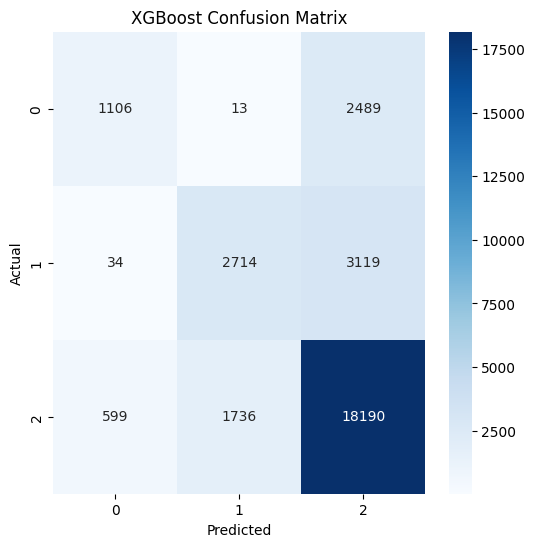

Training AdaBoost...

AdaBoost Evaluation Metrics:
Accuracy: 0.69
Precision: 0.66
Recall: 0.69
F1-Score: 0.64
Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.11      0.19      3608
           1       0.53      0.27      0.36      5867
           2       0.72      0.92      0.80     20525

    accuracy                           0.69     30000
   macro avg       0.61      0.43      0.45     30000
weighted avg       0.66      0.69      0.64     30000



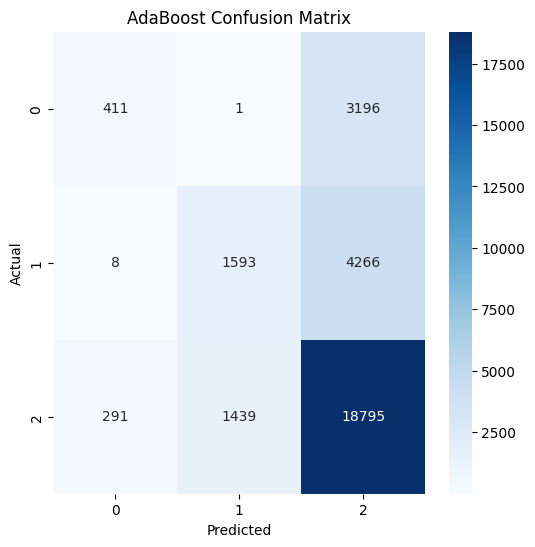

In [342]:

#  Define and Train Models
models = {
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42)
   
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    
    # Metrics Calculation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    class_report = classification_report(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    results[name] = {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Classification Report": class_report,
        "Confusion Matrix": conf_matrix
    }
    
    # Display results
    print(f"\n{name} Evaluation Metrics:")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"Precision: {precision:.2f}")
    print(f"Recall: {recall:.2f}")
    print(f"F1-Score: {f1:.2f}")
    print("Classification Report:")
    print(class_report)
    
    # Plot Confusion Matrix
    plt.figure(figsize=(6, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y), yticklabels=np.unique(y))
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


# 16.TAKING THE BEST MODEL

In [343]:
# Initialize the model (Random Forest Classifier in this case)
rf_model= RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [345]:
# Make predictions
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Display the results
print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1 Score: {f1:.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)


Model Evaluation Metrics:
Accuracy: 0.77
Precision: 0.76
Recall: 0.77
F1 Score: 0.76

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.48      0.56      3608
           1       0.66      0.58      0.62      5867
           2       0.81      0.87      0.84     20525

    accuracy                           0.77     30000
   macro avg       0.71      0.65      0.67     30000
weighted avg       0.76      0.77      0.76     30000

Confusion Matrix:
 [[ 1748     5  1855]
 [   11  3404  2452]
 [  869  1725 17931]]


# 17.SAVING THE BEST MODEL

In [346]:
import joblib
from sklearn.ensemble import RandomForestClassifier

# Assuming 'rf_model' is your trained Random Forest model
# For example: rf_model = RandomForestClassifier().fit(X_train, y_train)

# Save the model to a file
joblib.dump(rf_model, 'random_forest_model.pkl')

print("Random Forest model saved successfully as 'random_forest_model.pkl'")


Random Forest model saved successfully as 'random_forest_model.pkl'


In [347]:
# Load the model from the file
loaded_rf_model = joblib.load('random_forest_model.pkl')

print("Random Forest model loaded successfully!")


Random Forest model loaded successfully!


In [349]:
import pickle

# Save the model
with open('random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

# Load the model
with open('random_forest_model.pkl', 'rb') as f:
    loaded_rf_model = pickle.load(f)
